# Chicago Hit-and-Run Crash Prediction: A Multi-Dataset Analysis


## Introduction

Hit-and-run (H&R) collisions pose a critical road safety challenge: leaving the scene delays emergency response and significantly increases fatality risk (Tay et al., 2009). Research into the determinants of fleeing behaviour has identified several key factors. Male drivers, intoxicated individuals, and those driving stolen vehicles are significantly more prone to H&R (Kim et al., 2008). Studies of fatal pedestrian crashes show that drivers are more likely to flee at night or on weekends, when the perceived risk of apprehension is lower (Solnick and Hemenway, 1995).

Beyond driver attributes, the built environment also matters. Roadway alignment, speed limits, and traffic control devices independently influence the likelihood of fleeing a fatal crash scene (Tay et al., 2009). Methodologically, while early work relied on logistic regression and rough set analysis (Kim et al., 2008), recent scholarship employs machine learning to capture complex nonlinear interactions in high-dimensional crash data (Han et al., 2025).

One underexplored factor is nightlife proximity. Areas with dense alcohol-serving venues may elevate H&R risk through impaired driving and reduced inhibition, yet no multi-dataset study has tested this for Chicago. The present study addresses this gap by integrating crash, vehicle, person, and business licence data (2024–2025) to model H&R classification and evaluate nightlife proximity relative to behavioural, temporal, and environmental features.

## Research Questions

**Primary:** To what extent does spatial proximity to nightlife areas and liquor-licensed establishments serve as an effective predictor for classifying hit-and-run accidents in Chicago, compared to traditional environmental, infrastructural, and multi-actor (vehicle/pedestrian) features?

**Secondary:** Do the model's prediction errors exhibit significant spatial clustering, and what can be deduced from these clusters regarding the model's geographical blind spots?

## Data

Four datasets from the [City of Chicago Open Data Portal](https://data.cityofchicago.org/) were integrated, covering crashes from January 2024 to early 2025: the primary [**Traffic Crashes**](https://data.cityofchicago.org/Transportation/Traffic-Crashes-Crashes/85ca-t3if/about_data) table (~221,000 records, 30.6% H&R), [**Vehicles**](https://data.cityofchicago.org/Transportation/Traffic-Crashes-Vehicles/68nd-jvt3/about_data) and [**People**](https://data.cityofchicago.org/Transportation/Traffic-Crashes-People/u6pd-qa9d/about_data) records linked per crash, and [**Business Licences**](https://data.cityofchicago.org/Community-Economic-Development/Business-Licenses/r5kz-chrr/about_data) for active liquor-licensed establishments used to derive the nightlife density feature.

**Feature selection rationale** The key modelling decision is determining what information is realistically available at the moment a 911 call is received, before any officer investigation, laboratory test, or post-crash action has occurred. Features available at this point include crash location and time, road geometry and conditions, weather, and the number and basic demographics of persons remaining at the scene. Post-crash outcomes such as alcohol test results were excluded.

UNKNOWN values in officer-recorded fields were retained as informative signals: when a driver flees, officers cannot complete many documentation fields, so informational absence is itself a predictive feature.

Vehicle and person-level records were aggregated to crash level (mean, minimum, and maximum per crash) and joined to the crash table. The dataset was split 80/20 using stratified sampling.


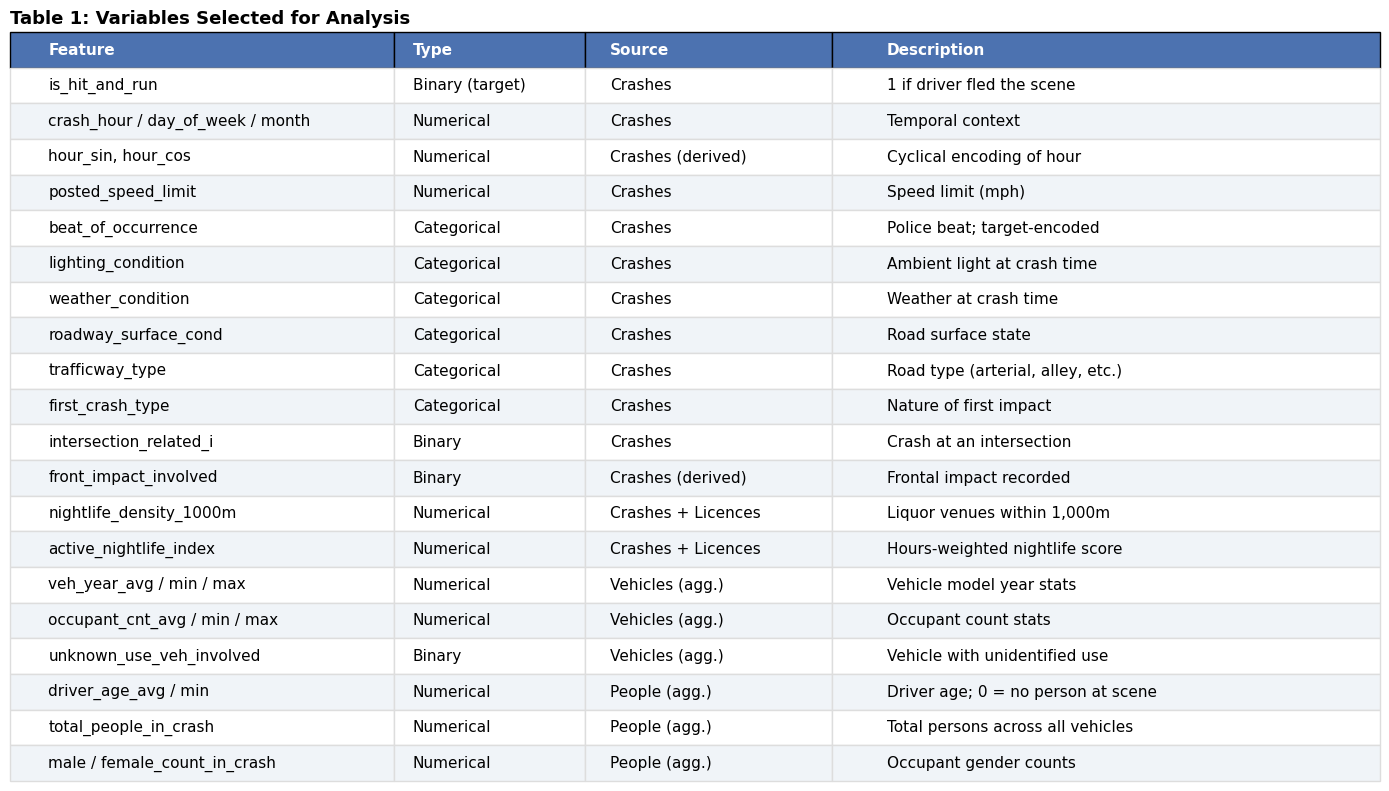

In [40]:
import matplotlib.pyplot as plt
import matplotlib as mpl

columns = ['Feature', 'Type', 'Source', 'Description']
data = [
    ["is_hit_and_run",                          "Binary (target)",       "Crashes",                  "1 if driver fled the scene"],
    ["crash_hour / day_of_week / month",        "Numerical",             "Crashes",                  "Temporal context"],
    ["hour_sin, hour_cos",                      "Numerical",             "Crashes (derived)",        "Cyclical encoding of hour"],
    ["posted_speed_limit",                      "Numerical",             "Crashes",                  "Speed limit (mph)"],
    ["beat_of_occurrence",                      "Categorical",           "Crashes",                  "Police beat; target-encoded"],
    ["lighting_condition",                      "Categorical",           "Crashes",                  "Ambient light at crash time"],
    ["weather_condition",                       "Categorical",           "Crashes",                  "Weather at crash time"],
    ["roadway_surface_cond",                    "Categorical",           "Crashes",                  "Road surface state"],
    ["trafficway_type",                         "Categorical",           "Crashes",                  "Road type (arterial, alley, etc.)"],
    ["first_crash_type",                        "Categorical",           "Crashes",                  "Nature of first impact"],
    ["intersection_related_i",                  "Binary",                "Crashes",                  "Crash at an intersection"],
    ["front_impact_involved",                   "Binary",                "Crashes (derived)",        "Frontal impact recorded"],
    ["nightlife_density_1000m",                 "Numerical",             "Crashes + Licences",       "Liquor venues within 1,000m"],
    ["active_nightlife_index",                  "Numerical",             "Crashes + Licences",       "Hours-weighted nightlife score"],
    ["veh_year_avg / min / max",                "Numerical",             "Vehicles (agg.)",          "Vehicle model year stats"],
    ["occupant_cnt_avg / min / max",            "Numerical",             "Vehicles (agg.)",          "Occupant count stats"],
    ["unknown_use_veh_involved",                "Binary",                "Vehicles (agg.)",          "Vehicle with unidentified use"],
    ["driver_age_avg / min",                    "Numerical",             "People (agg.)",            "Driver age; 0 = no person at scene"],
    ["total_people_in_crash",                   "Numerical",             "People (agg.)",            "Total persons across all vehicles"],
    ["male / female_count_in_crash",            "Numerical",             "People (agg.)",            "Occupant gender counts"],
]

fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('off')
ax.set_title('Table 1: Variables Selected for Analysis',
             fontweight='bold', fontsize=13, loc='left', pad=12)

table = ax.table(cellText=data, colLabels=columns,
                 cellLoc='left', loc='center', colLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)

# Style header row
for j in range(len(columns)):
    cell = table[0, j]
    cell.set_facecolor('#4C72B0')
    cell.set_text_props(color='white', fontweight='bold')

# Alternate row shading
for i in range(1, len(data) + 1):
    color = '#F0F4F8' if i % 2 == 0 else 'white'
    for j in range(len(columns)):
        table[i, j].set_facecolor(color)
        table[i, j].set_edgecolor('#DDDDDD')

# Set column widths
col_widths = [0.28, 0.14, 0.18, 0.40]
for j, w in enumerate(col_widths):
    for i in range(len(data) + 1):
        table[i, j].set_width(w)

plt.tight_layout()
plt.show()


In [ ]:
!pip install -q xgboost lightgbm

In [41]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import requests
import os
import time
import gc
import contextily as cx
import sklearn
from sklearn.model_selection import train_test_split

# Make all sklearn transformers output pandas DataFrames — preserves feature
# names through the pipeline (fixes LightGBM "no feature names" warning)
sklearn.set_config(transform_output="pandas")

# --- Configuration Flags ---
# NOTE: The full data-acquisition pipeline (API download, multi-table join,
# spatial nightlife join) is preserved in the cells below but disabled by
# default so the notebook runs quickly from the pre-built parquet files
# hosted on GitHub.  To reproduce from scratch, set both flags to True;
# the pipeline will re-download raw data from the Chicago Data Portal and
# rebuild the final datasets (~30-40 min depending on connection speed).
FORCE_DOWNLOAD = False        # Set True to re-download all raw data
PERFORM_INTEGRATION = False   # Set True to re-run the full join/integration

# --- Local Data Paths ---
RAW_CRASHES_FILE   = "raw_crashes.parquet"
RAW_VEHICLES_FILE  = "raw_vehicles.parquet"
RAW_PEOPLE_FILE    = "raw_people.parquet"
NIGHTLIFE_FILE     = "nightlife_licenses.parquet"
FINAL_TRAIN_FILE   = "train_crashes_final.parquet"
FINAL_TEST_FILE    = "test_crashes_final.parquet"

# Auto-download processed parquets from GitHub if not present locally
_GITHUB_RAW = "https://raw.githubusercontent.com/casagochman/chicago-hit-and-run/main/multi_ds"
for _f in [FINAL_TRAIN_FILE, FINAL_TEST_FILE]:
    if not os.path.exists(_f):
        print(f"Downloading {_f} from GitHub...")
        import urllib.request
        urllib.request.urlretrieve(f"{_GITHUB_RAW}/{_f}", _f)
        print(f"  Saved {_f}")

# --- Visualization Settings ---
HNR_LABELS  = {0: "Normal", 1: "Hit-and-Run"}
HNR_PALETTE = ["#3498db", "#e74c3c"]   # blue = normal, red = H&R

def apply_map_style(ax, title):
    try:
        cx.add_basemap(ax, crs="EPSG:32616", source=cx.providers.CartoDB.Positron, zoom=11)
    except Exception:
        pass
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_axis_off()

def engineer_features(df):
    """
    Applies derived feature engineering to a crash dataframe.
    Safe to call on both freshly-integrated and parquet-loaded data —
    skips columns that already exist so it is idempotent.
    """
    df = df.copy()

    # Cyclic encoding
    # Hour and day-of-week are circular; raw integers mislead tree models
    # (hour 23 and hour 0 are adjacent but numerically far apart).
    if "hour_sin" not in df.columns:
        df["hour_sin"] = np.sin(2 * np.pi * df["crash_hour"] / 24)
        df["hour_cos"] = np.cos(2 * np.pi * df["crash_hour"] / 24)
    if "dow_sin" not in df.columns:
        df["dow_sin"] = np.sin(2 * np.pi * df["crash_day_of_week"] / 7)
        df["dow_cos"] = np.cos(2 * np.pi * df["crash_day_of_week"] / 7)

    # Deep night flag
    # EDA showed H&R rate spikes to ~46% between midnight and 4am regardless
    # of whether it is a weekend — a sharper signal than is_weekend_night alone.
    if "is_deep_night" not in df.columns:
        df["is_deep_night"] = df["crash_hour"].isin(range(0, 5)).astype(int)

    # Vehicle year spread
    # Gap between newest and oldest vehicle in the crash. Hypothesis: an old
    # car striking a new one (or vice versa) may correlate with flight behaviour.
    if "veh_year_spread" not in df.columns:
        df["veh_year_spread"] = (df["veh_year_max"] - df["veh_year_min"]).fillna(0)

    return df

In [42]:
# --- Socrata API endpoints ---
CRASHES_URL   = "https://data.cityofchicago.org/resource/85ca-t3if.json"
VEHICLES_URL  = "https://data.cityofchicago.org/resource/68nd-jvt3.json"
PEOPLE_URL    = "https://data.cityofchicago.org/resource/u6pd-qa9d.json"
NIGHTLIFE_URL = "https://data.cityofchicago.org/resource/r5kz-chrr.json"

DATE_FILTER = "crash_date >= '2024-01-01T00:00:00'"

# --- Download crashes ---
if FORCE_DOWNLOAD:
    print("Downloading crashes...")
    df_crashes_raw = fetch_socrata_chunked(CRASHES_URL, DATE_FILTER)
    df_crashes_raw.columns = df_crashes_raw.columns.str.lower()
    df_crashes_raw.to_parquet(RAW_CRASHES_FILE, index=False)
    print(f"  Saved {len(df_crashes_raw):,} crash records.")
else:
    print(f"Crashes cache found ({RAW_CRASHES_FILE}), skipping download.")

# --- Download vehicles ---
if FORCE_DOWNLOAD:
    print("Downloading vehicles...")
    df_vehicles_raw = fetch_socrata_chunked(VEHICLES_URL, DATE_FILTER)
    df_vehicles_raw.columns = df_vehicles_raw.columns.str.lower()
    df_vehicles_raw.to_parquet(RAW_VEHICLES_FILE, index=False)
    print(f"  Saved {len(df_vehicles_raw):,} vehicle records.")
else:
    print(f"Vehicles cache found ({RAW_VEHICLES_FILE}), skipping download.")

# --- Download people ---
if FORCE_DOWNLOAD:
    print("Downloading people...")
    df_people_raw = fetch_socrata_chunked(PEOPLE_URL, DATE_FILTER)
    df_people_raw.columns = df_people_raw.columns.str.lower()
    df_people_raw.to_parquet(RAW_PEOPLE_FILE, index=False)
    print(f"  Saved {len(df_people_raw):,} people records.")
else:
    print(f"People cache found ({RAW_PEOPLE_FILE}), skipping download.")

# --- Download nightlife/liquor business licenses ---
if FORCE_DOWNLOAD:
    print("Downloading nightlife licenses...")
    LIQUOR_FILTER = "license_description like '%LIQUOR%' AND license_status = 'AAI'"
    df_nightlife_raw = fetch_socrata_chunked(NIGHTLIFE_URL, LIQUOR_FILTER)
    df_nightlife_raw.columns = df_nightlife_raw.columns.str.lower()
    df_nightlife_raw = df_nightlife_raw.dropna(subset=['latitude', 'longitude'])
    df_nightlife_raw.to_parquet(NIGHTLIFE_FILE, index=False)
    print(f"  Saved {len(df_nightlife_raw):,} nightlife license records.")
else:
    print(f"Nightlife cache found ({NIGHTLIFE_FILE}), skipping download.")


Crashes cache found (raw_crashes.parquet), skipping download.
Vehicles cache found (raw_vehicles.parquet), skipping download.
People cache found (raw_people.parquet), skipping download.
Nightlife cache found (nightlife_licenses.parquet), skipping download.


In [43]:
if PERFORM_INTEGRATION:
    print("Loading raw data...")
    df_c   = pd.read_parquet(RAW_CRASHES_FILE)
    df_veh = pd.read_parquet(RAW_VEHICLES_FILE)
    df_ppl = pd.read_parquet(RAW_PEOPLE_FILE)
    gdf_bars = pd.read_parquet(NIGHTLIFE_FILE)

    # Target variable
    df_c["is_hit_and_run"] = (df_c["hit_and_run_i"].fillna("N") == "Y").astype(int)

    # Leakage removal
    # Exclude post-crash administrative outcomes and identifiers that could not
    # be known at the time of initial crash reporting (~1-2 hour deployment window).
    LEAKAGE_COLS = [
        "bac_result", "physical_condition", "towed_i", "towed_by", "fire_i",
        "hospital", "ems_agency", "arrest_related_i", "statements_taken_i",
        "photos_taken_i", "report_type", "crash_date_est_i", "lane_cnt",
        "work_zone_type", "workers_present_i", "location",
        "date_police_notified", "hit_and_run_i",
        "prim_contributory_cause", "sec_contributory_cause",
    ]
    df_c = df_c.drop(columns=[c for c in LEAKAGE_COLS if c in df_c.columns], errors="ignore")

In [44]:
if PERFORM_INTEGRATION:
    # Structural flag columns
    FLAG_COLS = [
        "intersection_related_i", "private_property_i", "dooring_i", "work_zone_i",
    ]
    for col in FLAG_COLS:
        df_c[col] = (df_c[col].fillna("N") == "Y").astype(int)

    # Injury counts (officer-observable at scene)
    INJURY_COLS = [
        "injuries_total", "injuries_fatal", "injuries_incapacitating",
        "injuries_non_incapacitating", "injuries_reported_not_evident",
        "injuries_no_indication", "injuries_unknown",
    ]
    for col in INJURY_COLS:
        df_c[col] = pd.to_numeric(df_c[col], errors="coerce").fillna(0)

    # Coordinate cleaning (must precede spatial join)
    df_c["latitude"]  = pd.to_numeric(df_c["latitude"],  errors="coerce")
    df_c["longitude"] = pd.to_numeric(df_c["longitude"], errors="coerce")
    n_before = len(df_c)
    df_c = df_c.dropna(subset=["latitude", "longitude"])
    print(f"  Dropped {n_before - len(df_c):,} rows with missing coordinates.")

In [45]:
if PERFORM_INTEGRATION:
    # Vehicle aggregation
    df_veh["vehicle_year"]  = pd.to_numeric(df_veh.get("vehicle_year",  pd.Series(dtype=float)), errors="coerce")
    df_veh.loc[(df_veh["vehicle_year"] < 1900) | (df_veh["vehicle_year"] > 2026), "vehicle_year"] = np.nan
    df_veh["occupant_cnt"]  = pd.to_numeric(df_veh.get("occupant_cnt",  pd.Series(dtype=float)), errors="coerce").fillna(0)

    # Binary per-vehicle indicators
    df_veh["front_impact_involved"]    = df_veh.get("first_contact_point", pd.Series(dtype=str)).str.contains("FRONT", na=False).astype(int)
    df_veh["backing_maneuver_involved"]= (df_veh.get("maneuver", pd.Series(dtype=str)) == "BACKING").astype(int)
    df_veh["truck_involved"]           = df_veh.get("vehicle_type", pd.Series(dtype=str)).str.contains("TRUCK|TRACTOR", na=False).astype(int)
    df_veh["commercial_veh_involved"]  = df_veh.get("vehicle_use",  pd.Series(dtype=str)).str.contains("COMMERCIAL|TAXI|RIDESHARE", na=False).astype(int)
    df_veh["unknown_use_veh_involved"] = df_veh.get("vehicle_use",  pd.Series(dtype=str)).fillna("UNKNOWN").str.contains("UNKNOWN", na=False).astype(int)
    df_veh["unknown_type_veh_involved"]= df_veh.get("vehicle_type", pd.Series(dtype=str)).fillna("UNKNOWN").str.contains("UNKNOWN", na=False).astype(int)
    df_veh["speeding_involved"]        = (df_veh.get("exceed_speed_limit_i", pd.Series(dtype=str)).fillna("N") == "Y").astype(int)
    df_veh["vehicle_defect_involved"]  = (~df_veh.get("vehicle_defect", pd.Series(dtype=str)).fillna("NONE").str.upper().str.strip().isin(["NONE", "UNKNOWN", ""])).astype(int)
    df_veh["non_motor_unit_involved"]  = (~df_veh.get("unit_type", pd.Series(dtype=str)).fillna("").str.upper().str.strip().str.startswith("MOTOR")).astype(int)

    v_agg = df_veh.groupby("crash_record_id").agg(
        total_vehicles_in_crash  =("crash_unit_id",          "count"),
        veh_year_avg             =("vehicle_year",           "mean"),
        veh_year_min             =("vehicle_year",           "min"),
        veh_year_max             =("vehicle_year",           "max"),
        occupant_cnt_avg         =("occupant_cnt",           "mean"),
        occupant_cnt_min         =("occupant_cnt",           "min"),
        occupant_cnt_max         =("occupant_cnt",           "max"),
        truck_involved           =("truck_involved",         "max"),
        commercial_veh_involved  =("commercial_veh_involved","max"),
        front_impact_involved    =("front_impact_involved",  "max"),
        backing_maneuver_involved=("backing_maneuver_involved","max"),
        unknown_use_veh_involved =("unknown_use_veh_involved","max"),
        unknown_type_veh_involved=("unknown_type_veh_involved","max"),
        speeding_involved        =("speeding_involved",      "max"),
        vehicle_defect_involved  =("vehicle_defect_involved","max"),
        non_motor_unit_involved  =("non_motor_unit_involved","max"),
    )



In [46]:
if PERFORM_INTEGRATION:
    # People aggregation
    person_type_col    = df_ppl.get("person_type",    pd.Series(dtype=str)).fillna("").str.upper()
    driver_action_col  = df_ppl.get("driver_action",  pd.Series(dtype=str)).fillna("").str.upper()
    driver_vision_col  = df_ppl.get("driver_vision",  pd.Series(dtype=str)).fillna("UNKNOWN").str.upper()
    ejection_col       = df_ppl.get("ejection",       pd.Series(dtype=str)).fillna("UNKNOWN").str.upper()
    age_col            = pd.to_numeric(df_ppl.get("age", pd.Series(dtype=float)), errors="coerce")

    df_ppl["is_male"]               = (df_ppl.get("sex", pd.Series(dtype=str)) == "M").astype(int)
    df_ppl["is_female"]             = (df_ppl.get("sex", pd.Series(dtype=str)) == "F").astype(int)
    df_ppl["airbag_deployed"]       = df_ppl.get("airbag_deployed", pd.Series(dtype=str)).str.contains("DEPLOYED", na=False).astype(int)
    df_ppl["pedestrian_involved"]   = person_type_col.str.contains("PEDESTRIAN", na=False).astype(int)
    df_ppl["cyclist_involved"]      = person_type_col.str.contains("BICYCLE|CYCLIST|PEDALCYCLIST", na=False).astype(int)
    df_ppl["driver_vision_obscured"]= (~driver_vision_col.isin(["NOT OBSCURED", "UNKNOWN", ""])).astype(int)
    df_ppl["ejection_involved"]     = (~ejection_col.isin(["NOT EJECTED", "NONE", "UNKNOWN", ""])).astype(int)
    df_ppl["cell_phone_involved"]   = driver_action_col.str.contains("CELL", na=False).astype(int)
    df_ppl["age_numeric"]           = age_col.clip(lower=16, upper=100)

    p_agg = df_ppl.groupby("crash_record_id").agg(
        total_people_in_crash   =("person_id",            "count"),
        male_count_in_crash     =("is_male",              "sum"),
        female_count_in_crash   =("is_female",            "sum"),
        airbag_deployed_in_crash=("airbag_deployed",      "max"),
        pedestrian_involved     =("pedestrian_involved",  "max"),
        cyclist_involved        =("cyclist_involved",     "max"),
        driver_vision_obscured  =("driver_vision_obscured","max"),
        ejection_involved       =("ejection_involved",    "max"),
        cell_phone_involved     =("cell_phone_involved",  "max"),
        driver_age_avg          =("age_numeric",          "mean"),
        driver_age_min          =("age_numeric",          "min"),
    )

### Feature Engineering

Several features were derived from raw columns:

**Cyclical time encoding.** Hour and day-of-week are projected onto a unit circle (`sin`/`cos`) so that adjacent times (e.g. 23:00 and 00:00) remain numerically close. Raw values are retained alongside.

**Deep-night flag (`is_deep_night`).** Binary indicator for crashes between 00:00 and 04:59.

**Vehicle year spread (`veh_year_spread`).** Gap between newest and oldest vehicle, proxying flight incentive.

**Crash-type flags.** `front_impact_involved`, `pedestrian_involved`, and `cyclist_involved` - binary signals derived from `first_crash_type`.

**Nightlife density.** A spatial join counts active liquor-licensed venues within 1,000m of each crash. `active_nightlife_index` weights by operating hours. These operationalise the spatial proximity hypothesis.

**Vehicle- and person-level aggregations.** Records are aggregated to crash level (mean, min, max). Notably, `driver_age_avg = 0` when no persons are recorded at scene — a strong signal that the driver fled.


In [47]:
if PERFORM_INTEGRATION:
    # Spatial feature: nightlife density within 1000 m
    gdf_c_temp = gpd.GeoDataFrame(
        df_c[["crash_record_id"]],
        geometry=gpd.points_from_xy(df_c.longitude, df_c.latitude),
        crs="EPSG:4326"
    ).to_crs("EPSG:32616")

    gdf_bars_temp = gpd.GeoDataFrame(
        gdf_bars[["longitude", "latitude"]],
        geometry=gpd.points_from_xy(
            pd.to_numeric(gdf_bars.longitude, errors="coerce"),
            pd.to_numeric(gdf_bars.latitude,  errors="coerce")
        ),
        crs="EPSG:4326"
    ).to_crs("EPSG:32616")
    gdf_bars_temp = gdf_bars_temp.dropna(subset=["geometry"])

    buffered = gdf_c_temp[["geometry"]].copy()
    buffered["geometry"] = buffered.geometry.buffer(1000)
    joined = gpd.sjoin(buffered, gdf_bars_temp[["geometry"]], how="inner", predicate="intersects")
    df_c["nightlife_density_1000m"] = (
        joined.groupby(joined.index).size().reindex(df_c.index, fill_value=0)
    )

    # Temporal feature engineering
    df_c["crash_hour"]        = pd.to_numeric(df_c["crash_hour"],        errors="coerce").fillna(0).astype(int)
    df_c["crash_day_of_week"] = pd.to_numeric(df_c["crash_day_of_week"], errors="coerce").fillna(0).astype(int)
    df_c["crash_month"]       = pd.to_numeric(df_c["crash_month"],       errors="coerce").fillna(0).astype(int)

    # Weekend night: Friday (6) or Saturday (7), 22:00–04:00
    is_night       = df_c["crash_hour"].isin(list(range(22, 24)) + list(range(0, 5)))
    is_weekend     = df_c["crash_day_of_week"].isin([6, 7])
    df_c["is_weekend_night"] = (is_night & is_weekend).astype(int)

    # Active nightlife index: density × time-of-night weight (higher at night)
    night_weight = np.where(
        df_c["crash_hour"].isin(list(range(22, 24)) + list(range(0, 5))), 2.0,
        np.where(df_c["crash_hour"].isin(range(17, 22)), 1.2, 0.5)
    )
    df_c["active_nightlife_index"] = df_c["nightlife_density_1000m"] * night_weight

    # Merge all datasets
    df_final = (
        df_c
        .merge(v_agg, on="crash_record_id", how="left")
        .merge(p_agg, on="crash_record_id", how="left")
    )

    # Fill aggregation nulls (crashes with no vehicle/people records linked)
    fill_cols = list(v_agg.columns) + list(p_agg.columns)
    df_final[fill_cols] = df_final[fill_cols].fillna(0)

    # Derived feature engineering
    df_final = engineer_features(df_final)

    # Stratified train/test split
    gdf_final = gpd.GeoDataFrame(
        df_final,
        geometry=gpd.points_from_xy(df_final.longitude, df_final.latitude),
        crs="EPSG:4326"
    )
    df_train, df_test = train_test_split(
        gdf_final, test_size=0.2, random_state=42,
        stratify=gdf_final["is_hit_and_run"]
    )
    df_train.to_parquet(FINAL_TRAIN_FILE)
    df_test.to_parquet(FINAL_TEST_FILE)
    print(f"Integration complete. Train: {len(df_train):,}  Test: {len(df_test):,}")
    del df_veh, df_ppl, gdf_bars, df_c, df_final
    gc.collect()

### Final Features

Single source of truth for which columns enter the model:


In [48]:
TARGET_COL = "is_hit_and_run"

# Continuous / ordinal numerics
NUMERICAL_FEATURES = [
    "crash_hour", "crash_day_of_week", "crash_month",
    "hour_sin", "hour_cos",          # cyclic encoding of hour
    "dow_sin",  "dow_cos",           # cyclic encoding of day-of-week
    "posted_speed_limit",
    "nightlife_density_1000m", "active_nightlife_index",
    "veh_year_avg", "veh_year_min", "veh_year_max", "veh_year_spread",
    "occupant_cnt_avg", "occupant_cnt_min", "occupant_cnt_max",
    "total_vehicles_in_crash", "total_people_in_crash",
    "injuries_total",
    "male_count_in_crash", "female_count_in_crash",
    "driver_age_avg", "driver_age_min",
]

# Categorical strings
CATEGORICAL_FEATURES = [
    "lighting_condition",
    "weather_condition",
    "roadway_surface_cond",
    "first_crash_type",
    "trafficway_type",
    "traffic_control_device",
    "road_defect",
    "beat_of_occurrence",
]

# Binary flags (0/1)
BINARY_FEATURES = [
    "intersection_related_i", "private_property_i", "dooring_i", "work_zone_i",
    "front_impact_involved", "backing_maneuver_involved",
    "truck_involved", "commercial_veh_involved",
    "unknown_use_veh_involved", "unknown_type_veh_involved",
    "speeding_involved", "vehicle_defect_involved", "non_motor_unit_involved",
    "airbag_deployed_in_crash",
    "pedestrian_involved", "cyclist_involved",
    "driver_vision_obscured", "ejection_involved", "cell_phone_involved",
    "is_weekend_night", "is_deep_night",
]

FEATURE_COLS = NUMERICAL_FEATURES + CATEGORICAL_FEATURES + BINARY_FEATURES

print(f"Feature matrix: {len(NUMERICAL_FEATURES)} numerical | "
      f"{len(CATEGORICAL_FEATURES)} categorical | "
      f"{len(BINARY_FEATURES)} binary | "
      f"{len(FEATURE_COLS)} total")

Feature matrix: 24 numerical | 8 categorical | 21 binary | 53 total


## Data Validation & Summary Statistics


In [49]:
gdf_train = gpd.read_parquet(FINAL_TRAIN_FILE)
print(f"Loaded {len(gdf_train):,} training records | {gdf_train.shape[1]} columns")

# Target balance
vc = gdf_train["is_hit_and_run"].value_counts(normalize=True)
print("Target distribution:")
print(vc.rename(index=HNR_LABELS).to_string())

# Coordinate bounds — confirm Chicago extents
print(f"\nLatitude:  {gdf_train.latitude.min():.4f} – {gdf_train.latitude.max():.4f}")
print(f"Longitude: {gdf_train.longitude.min():.4f} – {gdf_train.longitude.max():.4f}")

Loaded 175,053 training records | 74 columns
Target distribution:
is_hit_and_run
Normal         0.694418
Hit-and-Run    0.305582

Latitude:  0.0000 – 42.0228
Longitude: -87.9397 – 0.0000


## Exploratory Data Analysis

The EDA explores environmental, temporal, geographic, and feature-level patterns that motivate the predictor set.


In [50]:
df_eda = gpd.read_parquet(FINAL_TRAIN_FILE)

# Ensure numeric types for temporal columns
for _col in ["crash_hour", "crash_day_of_week", "crash_month", "posted_speed_limit"]:
    df_eda[_col] = pd.to_numeric(df_eda[_col], errors="coerce")

# Apply derived features (idempotent — safe to call on already-integrated data)
df_eda = engineer_features(df_eda)

BASELINE_RATE = df_eda["is_hit_and_run"].mean()
print(f"Training set: {len(df_eda):,} crashes | Baseline H&R rate: {BASELINE_RATE:.3f} ({BASELINE_RATE*100:.1f}%)")

Training set: 175,053 crashes | Baseline H&R rate: 0.306 (30.6%)


---

**Part II — Environmental, Temporal, and Spatial Patterns**


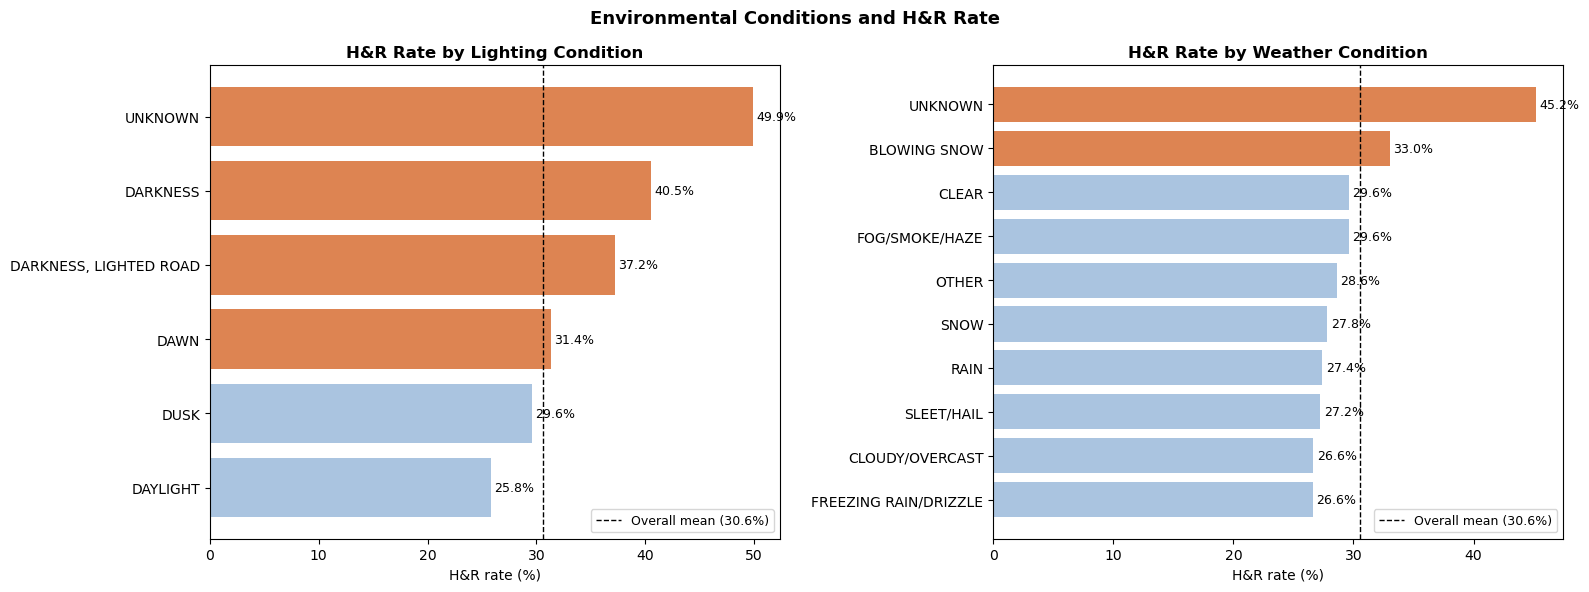

In [51]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
baseline = df_eda["is_hit_and_run"].mean() * 100

# Left: H&R rate by lighting condition
ax = axes[0]
lighting = (
    df_eda.groupby("lighting_condition")["is_hit_and_run"]
    .agg(["mean", "count"]).reset_index()
    .query("count >= 100")
    .sort_values("mean", ascending=True)
)
lighting["mean_pct"] = lighting["mean"] * 100
colors = ["#DD8452" if v > baseline else "#aac4e0" for v in lighting["mean_pct"]]
bars = ax.barh(lighting["lighting_condition"], lighting["mean_pct"], color=colors)
ax.axvline(baseline, color="black", linestyle="--", linewidth=1,
           label=f"Overall mean ({baseline:.1f}%)")
ax.set_xlabel("H&R rate (%)")
ax.set_title("H&R Rate by Lighting Condition", fontweight="bold")
ax.legend(fontsize=9)
for bar, v in zip(bars, lighting["mean_pct"]):
    ax.text(v + 0.3, bar.get_y() + bar.get_height()/2, f"{v:.1f}%", va="center", fontsize=9)

# Right: H&R rate by weather condition
ax = axes[1]
weather = (
    df_eda.groupby("weather_condition")["is_hit_and_run"]
    .agg(["mean", "count"]).reset_index()
    .query("count >= 100")
    .sort_values("mean", ascending=True)
)
weather["mean_pct"] = weather["mean"] * 100
colors = ["#DD8452" if v > baseline else "#aac4e0" for v in weather["mean_pct"]]
bars = ax.barh(weather["weather_condition"], weather["mean_pct"], color=colors)
ax.axvline(baseline, color="black", linestyle="--", linewidth=1,
           label=f"Overall mean ({baseline:.1f}%)")
ax.set_xlabel("H&R rate (%)")
ax.set_title("H&R Rate by Weather Condition", fontweight="bold")
ax.legend(fontsize=9)
for bar, v in zip(bars, weather["mean_pct"]):
    ax.text(v + 0.3, bar.get_y() + bar.get_height()/2, f"{v:.1f}%", va="center", fontsize=9)

plt.suptitle("Environmental Conditions and H&R Rate", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


Darkness raises H&R rate above the baseline; weather shows modest variation, suggesting lighting matters more than road conditions.


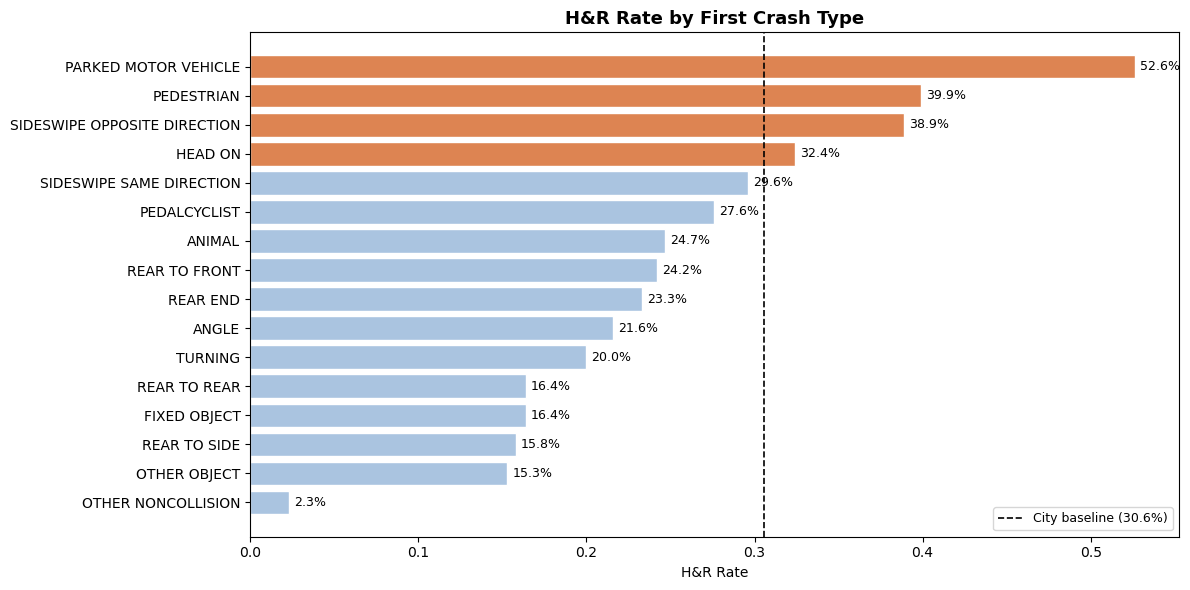

In [52]:
import matplotlib.pyplot as plt

baseline = df_eda["is_hit_and_run"].mean()

agg = (
    df_eda.groupby("first_crash_type")["is_hit_and_run"]
    .agg(hnr_rate="mean", count="size")
    .reset_index()
    .query("count >= 100")
    .sort_values("hnr_rate", ascending=True)
)
colors = ["#DD8452" if v > baseline else "#aac4e0" for v in agg["hnr_rate"]]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(agg["first_crash_type"], agg["hnr_rate"], color=colors, edgecolor="white")
ax.axvline(baseline, color="black", linestyle="--", linewidth=1.2,
           label=f"City baseline ({baseline*100:.1f}%)")
ax.set_xlabel("H&R Rate")
ax.set_title("H&R Rate by First Crash Type", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
for bar, v in zip(bars, agg["hnr_rate"]):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f"{v*100:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()


Parked-vehicle and pedestrian strikes far exceed the H&R baseline, while angle and rear-end collisions fall well below it.


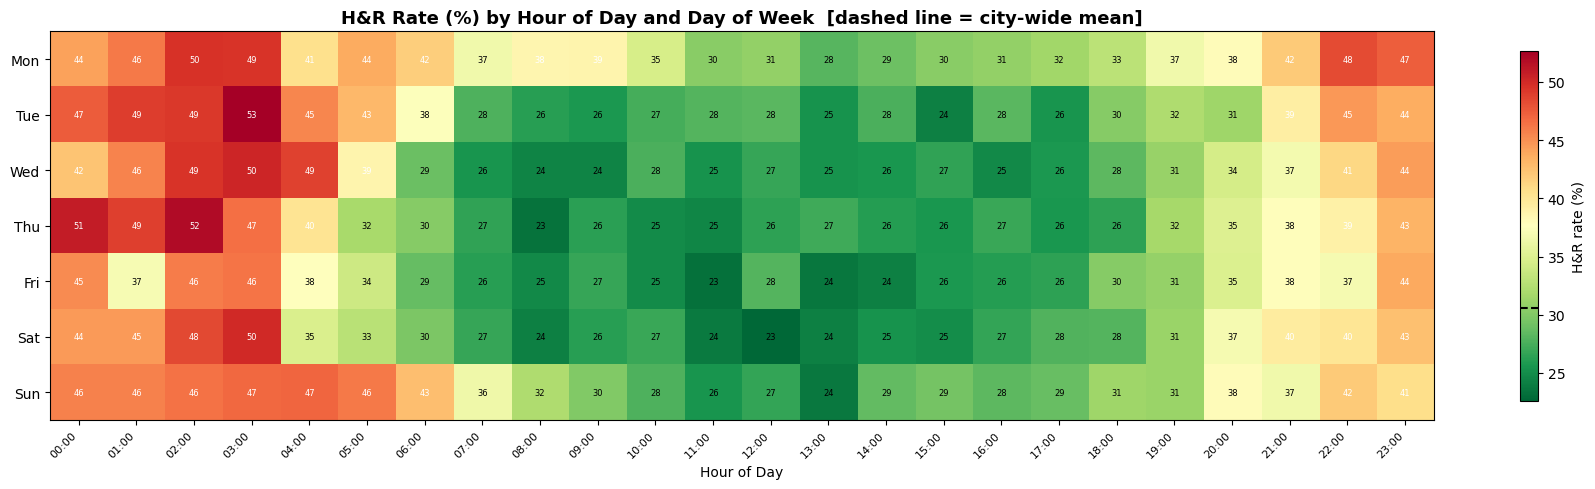

In [53]:
# 168-cell heatmap: H&R rate by hour of day × day of week
import matplotlib.pyplot as plt
import numpy as np

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

heatmap_data = (
    df_eda.groupby(['crash_day_of_week', 'crash_hour'])['is_hit_and_run']
    .mean() * 100
).unstack(level=1)
heatmap_data.index = day_labels

overall_mean = df_eda['is_hit_and_run'].mean() * 100

fig, ax = plt.subplots(figsize=(18, 5))
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='RdYlGn_r',
               vmin=heatmap_data.values.min(), vmax=heatmap_data.values.max())
cbar = plt.colorbar(im, ax=ax, label='H&R rate (%)', shrink=0.9)
cbar.ax.axhline(overall_mean, color='black', linewidth=1.5, linestyle='--')

ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(7))
ax.set_yticklabels(day_labels)
ax.set_xlabel('Hour of Day')
ax.set_title('H&R Rate (%) by Hour of Day and Day of Week  [dashed line = city-wide mean]',
             fontsize=13, fontweight='bold')

# Annotate each cell
for r in range(7):
    for col in range(24):
        v = heatmap_data.values[r, col]
        ax.text(col, r, f'{v:.0f}', ha='center', va='center',
                fontsize=6, color='white' if v > 38 else 'black')

plt.tight_layout()
plt.show()


Weekend late-night hours (Fri–Sat 22:00–04:00) carry the highest H&R risk, peaking above 50% in the 01:00–03:00 window.


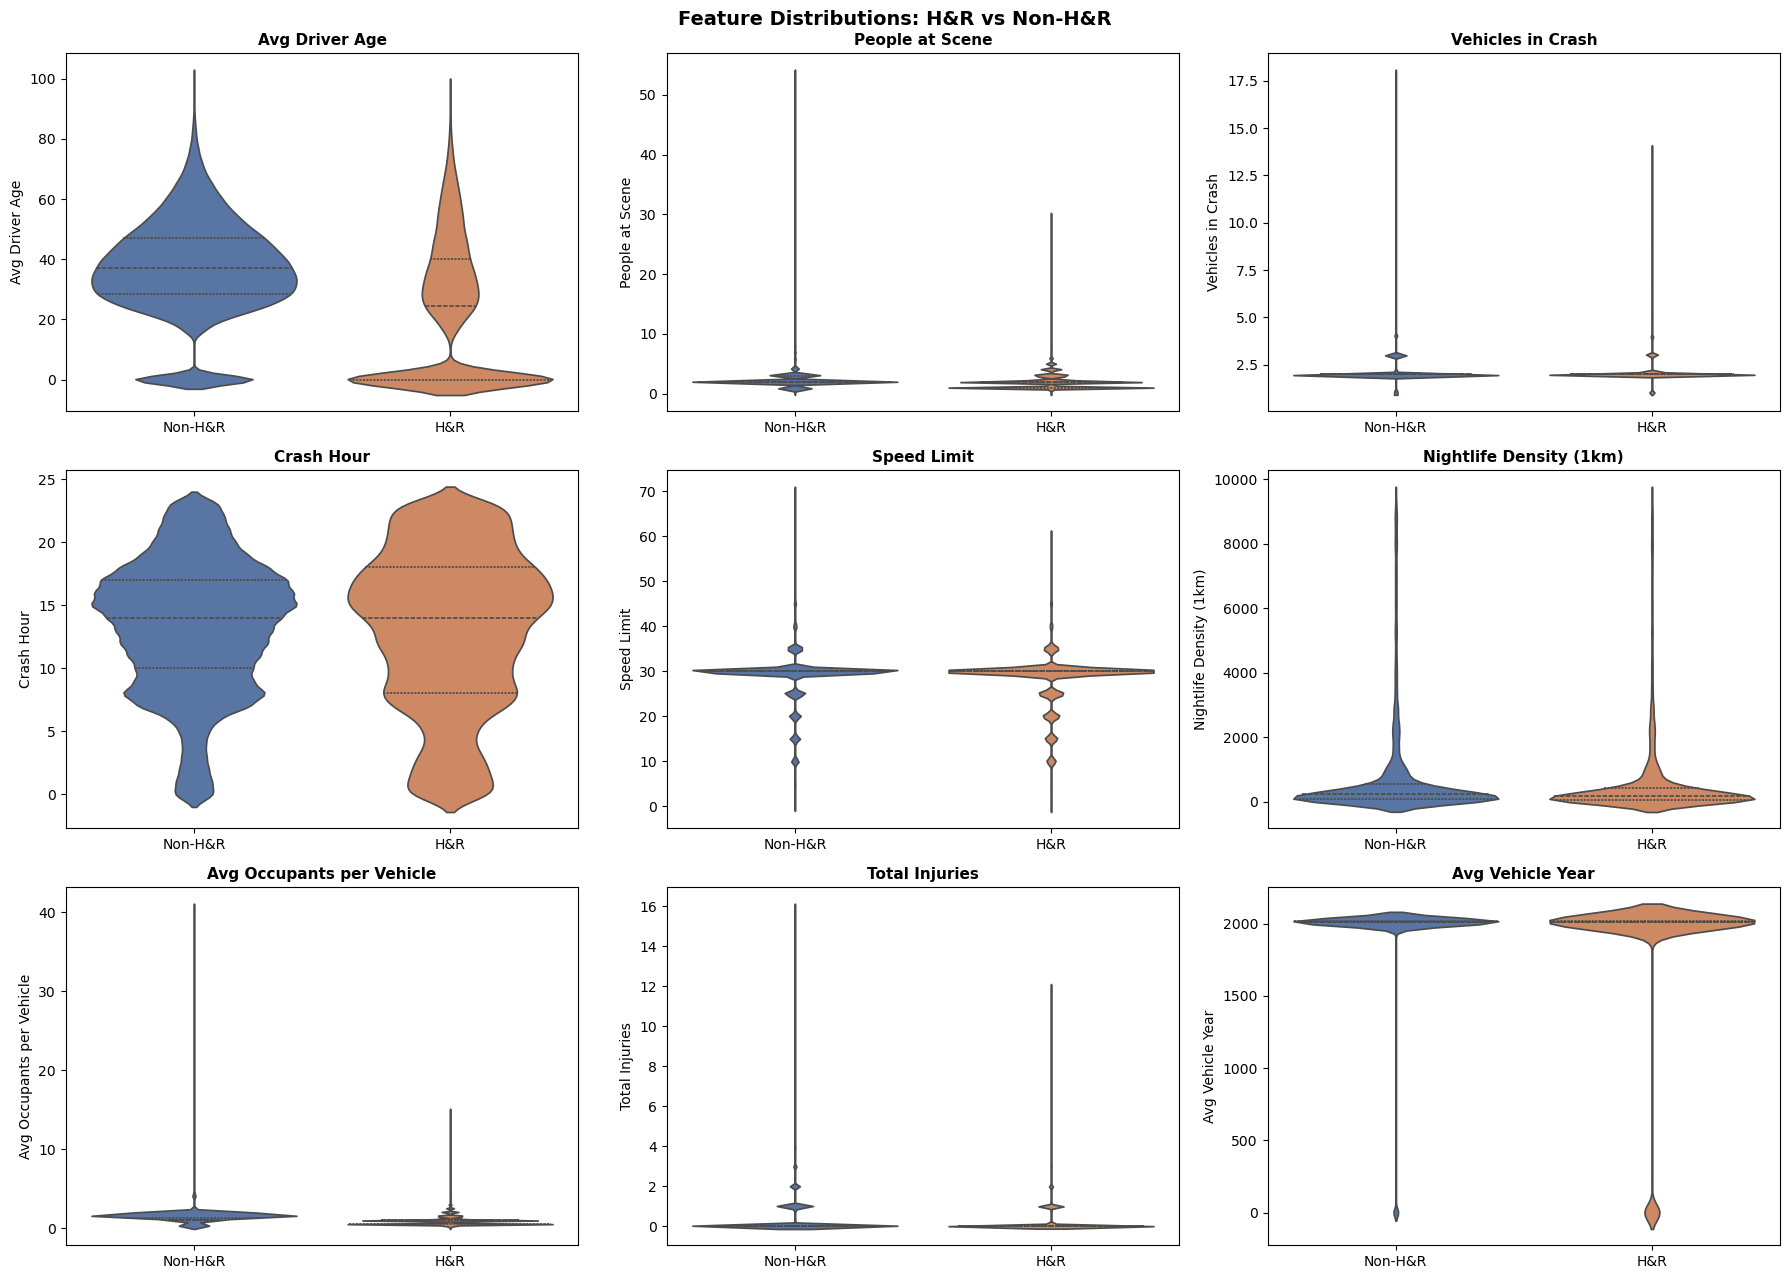

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Nine features chosen for their predictive relevance
VIOLIN_FEATURES = [
    ("driver_age_avg",            "Avg Driver Age"),
    ("total_people_in_crash",     "People at Scene"),
    ("total_vehicles_in_crash",   "Vehicles in Crash"),
    ("crash_hour",                "Crash Hour"),
    ("posted_speed_limit",        "Speed Limit"),
    ("nightlife_density_1000m",   "Nightlife Density (1km)"),
    ("occupant_cnt_avg",          "Avg Occupants per Vehicle"),
    ("injuries_total",            "Total Injuries"),
    ("veh_year_avg",              "Avg Vehicle Year"),
]

fig, axes = plt.subplots(3, 3, figsize=(18, 13))
palette = {0: "#4C72B0", 1: "#DD8452"}

for ax, (col, label) in zip(axes.flatten(), VIOLIN_FEATURES):
    if col not in df_eda.columns:
        ax.set_visible(False)
        continue
    plot_df = df_eda[[col, "is_hit_and_run"]].dropna()
    sns.violinplot(
        data=plot_df, x="is_hit_and_run", y=col,
        hue="is_hit_and_run", palette=palette,
        inner="quartile", legend=False, ax=ax
    )
    ax.set_xlabel("")
    ax.set_ylabel(label, fontsize=10)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Non-H&R", "H&R"])
    ax.set_title(label, fontsize=11, fontweight="bold")

fig.suptitle("Feature Distributions: H&R vs Non-H&R", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


`driver_age_avg` and `total_people_in_crash` show the starkest class separation: H&R crashes cluster near zero for both.


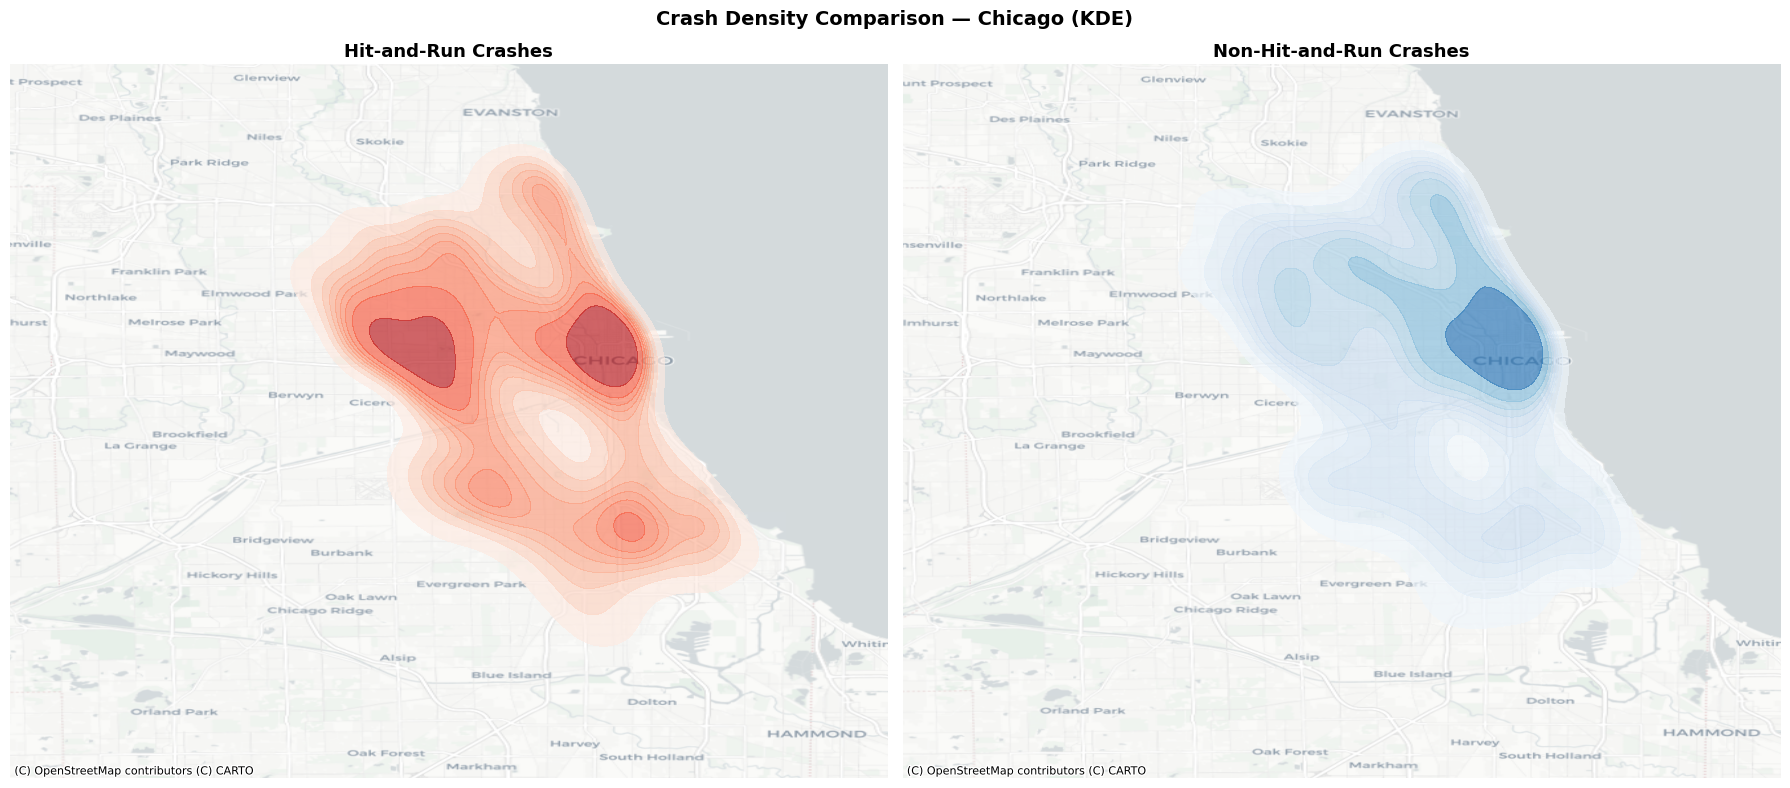

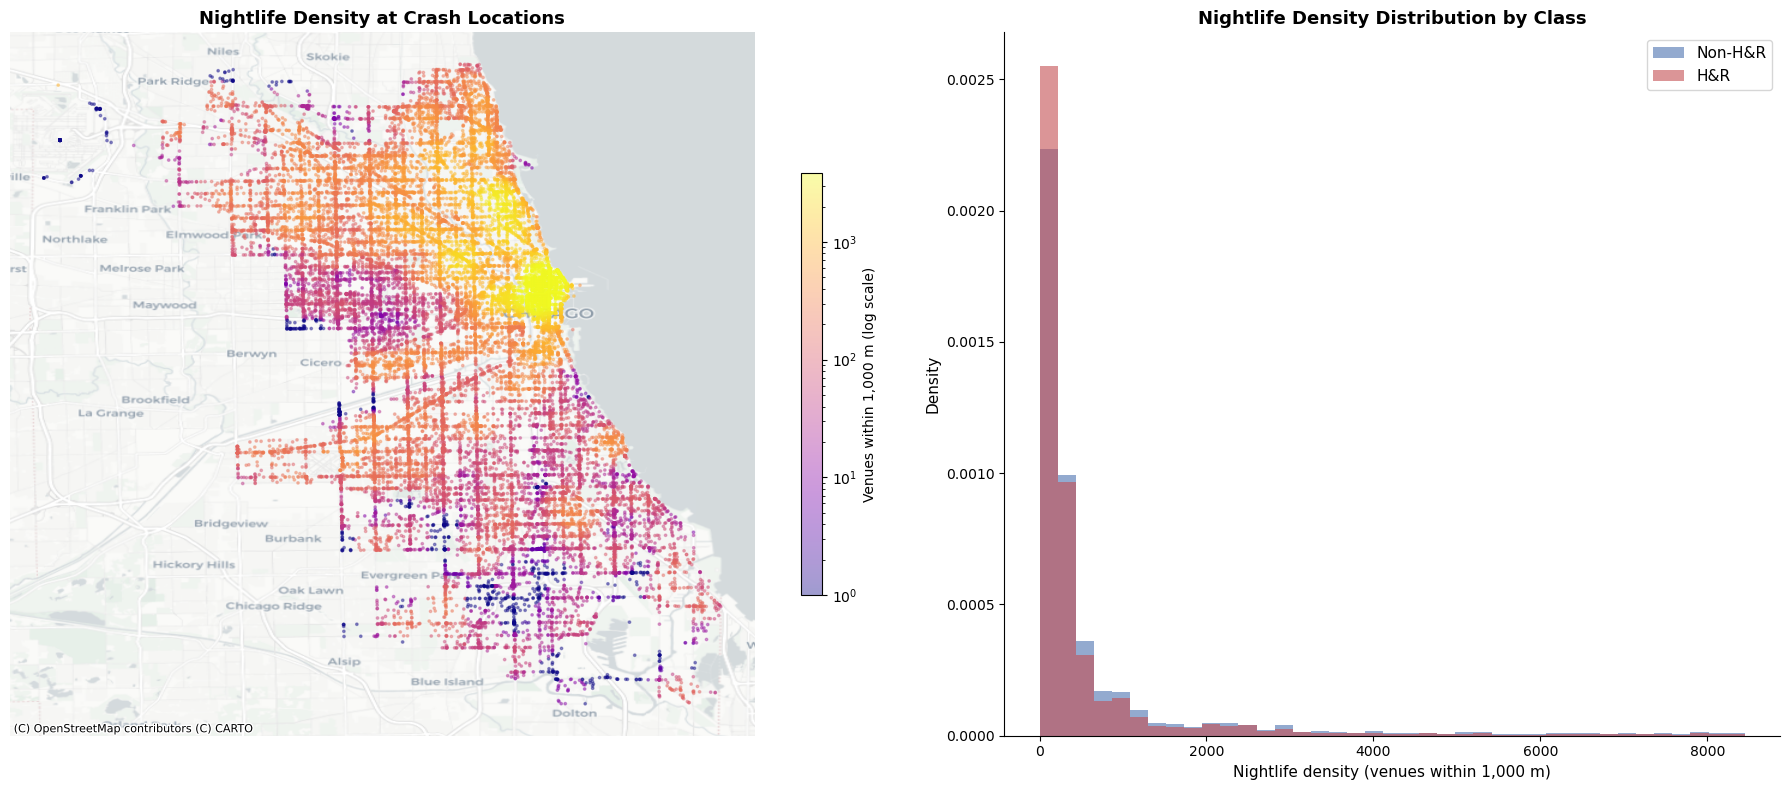

In [55]:
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# Free memory before map generation
gc.collect()

try:
    import contextily as cx
    HAS_CX = True
except ImportError:
    HAS_CX = False

gdf_map = gpd.GeoDataFrame(
    df_eda,
    geometry=gpd.points_from_xy(df_eda.longitude, df_eda.latitude),
    crs="EPSG:4326"
).to_crs("EPSG:32616")

sample = gdf_map.dropna(subset=["geometry"]).sample(min(25000, len(gdf_map)), random_state=42)
hnr_s  = sample[sample["is_hit_and_run"] == 1]
norm_s = sample[sample["is_hit_and_run"] == 0]

# Keep full sample for nightlife map
sample_full = sample.copy()

# Equal sample sizes for fair KDE comparison
n_min = min(len(hnr_s), len(norm_s))
hnr_s  = hnr_s.sample(n_min, random_state=42)
norm_s = norm_s.sample(n_min, random_state=42)

# --- Figure 1: H&R vs Non-H&R crash density ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, sub, title, cmap in [
    (axes[0], hnr_s,  "Hit-and-Run Crashes",  "Reds"),
    (axes[1], norm_s, "Non-Hit-and-Run Crashes", "Blues"),
]:
    sns.kdeplot(x=sub.geometry.x, y=sub.geometry.y,
                fill=True, cmap=cmap, alpha=0.65, ax=ax, thresh=0.15)
    if HAS_CX:
        try:
            cx.add_basemap(ax, crs="EPSG:32616",
                           source=cx.providers.CartoDB.Positron, zoom=11)
        except Exception:
            pass
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_axis_off()
plt.suptitle("Crash Density Comparison — Chicago (KDE)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Figure 2: Nightlife density — map + histogram ---
import numpy as np
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(1, 2, figsize=(18, 8),
                         gridspec_kw={'width_ratios': [1.2, 1]})

# Left: nightlife scatter map
ax = axes[0]
nl = sample_full["nightlife_density_1000m"].copy()
nl = nl.clip(lower=1)
sc = ax.scatter(
    sample_full.geometry.x, sample_full.geometry.y,
    c=nl, cmap='plasma', norm=LogNorm(vmin=1, vmax=nl.quantile(0.95)),
    s=3, alpha=0.4,
)
plt.colorbar(sc, ax=ax, shrink=0.6, label="Venues within 1,000 m (log scale)")
if HAS_CX:
    try:
        cx.add_basemap(ax, crs="EPSG:32616",
                       source=cx.providers.CartoDB.Positron, zoom=11)
    except Exception:
        pass
ax.set_title("Nightlife Density at Crash Locations", fontsize=13, fontweight="bold")
ax.set_axis_off()

# Right: overlaid histograms of nightlife density by class
ax2 = axes[1]
hnr_nl = sample_full.loc[sample_full["is_hit_and_run"] == 1, "nightlife_density_1000m"]
non_nl = sample_full.loc[sample_full["is_hit_and_run"] == 0, "nightlife_density_1000m"]
bins = np.linspace(0, non_nl.quantile(0.99), 40)
ax2.hist(non_nl, bins=bins, alpha=0.6, color='#4C72B0', label='Non-H&R', density=True)
ax2.hist(hnr_nl, bins=bins, alpha=0.6, color='#C44E52', label='H&R', density=True)
ax2.set_xlabel("Nightlife density (venues within 1,000 m)", fontsize=11)
ax2.set_ylabel("Density", fontsize=11)
ax2.set_title("Nightlife Density Distribution by Class", fontsize=13, fontweight="bold")
ax2.legend(fontsize=11)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

The KDE maps suggest a somewhat different spatial distribution between H&R and non-H&R crashes. The nightlife density histogram shows substantial overlap between the two classes, foreshadowing the weak independent contribution of this feature.


**EDA summary.** H&R crashes are dominated by opportunistic property-damage incidents, not violent crime. Risk peaks between 01:00–04:00, when witness exposure is minimal. Darkness raises the H&R rate markedly above the city-wide mean.


## Methodology

Following Han et al. (2025), the classifier is treated as a feature importance engine rather than a deployment system. A responding officer probably already knows whether a crash is a hit-and-run; the model's value lies in identifying which crash characteristics most strongly associate with that outcome. Three methods are applied.

**ML classifier**
A four-model comparison (Logistic Regression, Random Forest, XGBoost, LightGBM) using 5-fold stratified cross-validation selects the best-performing model. A randomized search optimises key hyperparameters. Class imbalance (70/30) is addressed via `class_weight="balanced"`. The classification threshold is chosen by maximising the F2 score, weighting recall twice as heavily as precision — a missed H&R crash is operationally costlier than a false alarm. Preprocessing includes target encoding for `beat_of_occurrence`, one-hot encoding for low-cardinality categoricals, and median imputation.

**SHAP** quantifies how much each feature contributes to individual predictions. Importantly, SHAP explains the model's decision-making, not causal relationships in the data.

**Beat-level spatial error analysis (Choropleth + Local Moran's I)**
Recall is computed per police beat and mapped across Chicago's 271 beats. Local Moran's I (LISA) is then applied to identify statistically significant Low-Low clusters — beats with below-average detection surrounded by similarly underperforming neighbours. Uses Queen contiguity weights (row-standardised).


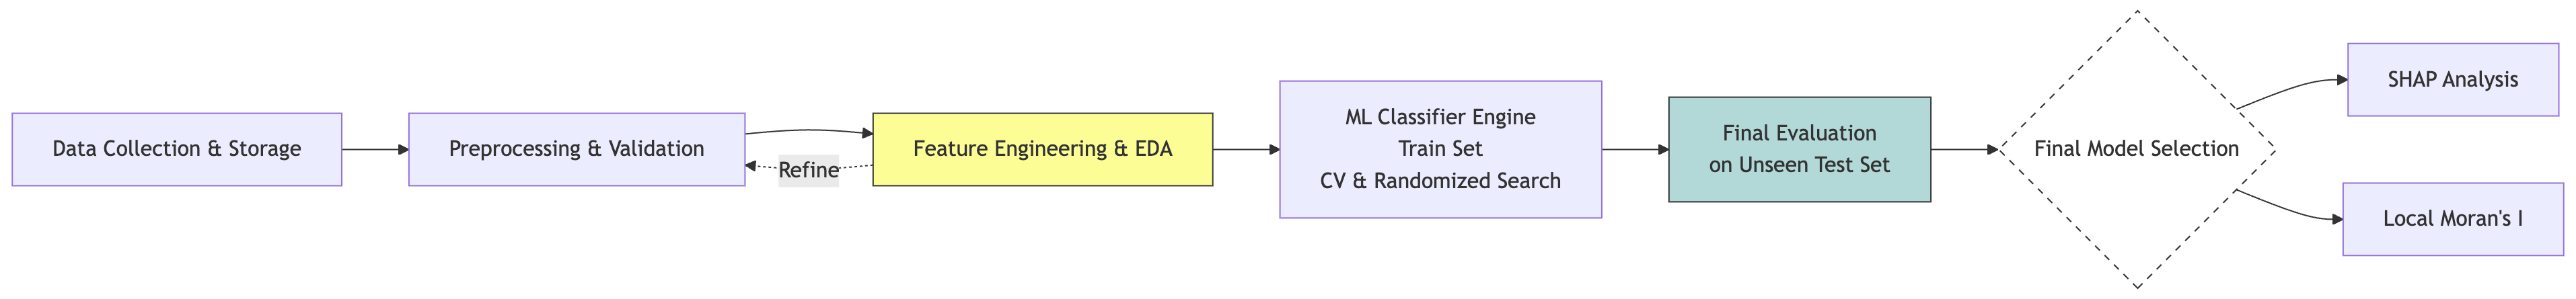

In [56]:
from IPython.display import Image, display
display(Image(url='https://raw.githubusercontent.com/casagochman/chicago-hit-and-run/main/multi_ds/methodology.png', width=900))


### Preprocessing Pipeline


In [57]:
import re
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

# Load splits
df_train = gpd.read_parquet(FINAL_TRAIN_FILE)
df_test  = gpd.read_parquet(FINAL_TEST_FILE)

df_train = engineer_features(df_train)
df_test  = engineer_features(df_test)

missing_cols = [c for c in FEATURE_COLS if c not in df_train.columns]
if missing_cols:
    print(f"WARNING: missing from train — {missing_cols}")

X_train = df_train[FEATURE_COLS].copy()
y_train = df_train[TARGET_COL].copy()
X_test  = df_test[FEATURE_COLS].copy()
y_test  = df_test[TARGET_COL].copy()

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train positive rate: {y_train.mean():.3f}  |  y_test: {y_test.mean():.3f}")

# Column groups
CAT_LOW  = [c for c in CATEGORICAL_FEATURES if c != "beat_of_occurrence"]
CAT_HIGH = ["beat_of_occurrence"]

# Feature name sanitizer
# OHE produces names like "first_crash_type_[ANGLE]" — LightGBM rejects
# special characters. This step replaces any non-alphanumeric char with _.
class FeatureNameSanitizer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        if hasattr(X, "columns"):
            X = X.copy()
            X.columns = [re.sub(r"[^a-zA-Z0-9_]", "_", c) for c in X.columns]
        return X

# Sub-transformers
num_pipe = SimpleImputer(strategy="median")

cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="UNKNOWN")),
    ("ohe",    OneHotEncoder(handle_unknown="infrequent_if_exist", sparse_output=False, min_frequency=50)),
])

beat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="UNKNOWN")),
    ("te",     TargetEncoder(target_type="binary", smooth="auto", cv=5, random_state=42)),
])

# Single preprocessor for all models
preprocessor = Pipeline([
    ("col_transform", ColumnTransformer([
        ("num",  num_pipe,      NUMERICAL_FEATURES),
        ("cat",  cat_pipe,      CAT_LOW),
        ("beat", beat_pipe,     CAT_HIGH),
        ("bin",  "passthrough", BINARY_FEATURES),
    ], remainder="drop", verbose_feature_names_out=False)),
    ("sanitize", FeatureNameSanitizer()),
    ("scale",    StandardScaler()),
])

print("\nPreprocessor defined.")
print(f"  Numerical ({len(NUMERICAL_FEATURES)}): {NUMERICAL_FEATURES[:3]}...")
print(f"  Categorical OHE ({len(CAT_LOW)}): {CAT_LOW}")
print(f"  Target encoded (1): beat_of_occurrence  [cv=5, random_state=42]")
print(f"  Binary passthrough ({len(BINARY_FEATURES)}): {BINARY_FEATURES[:3]}...")

X_train: (175053, 53)  |  X_test: (43764, 53)
y_train positive rate: 0.306  |  y_test: 0.306

Preprocessor defined.
  Numerical (24): ['crash_hour', 'crash_day_of_week', 'crash_month']...
  Categorical OHE (7): ['lighting_condition', 'weather_condition', 'roadway_surface_cond', 'first_crash_type', 'trafficway_type', 'traffic_control_device', 'road_defect']
  Target encoded (1): beat_of_occurrence  [cv=5, random_state=42]
  Binary passthrough (21): ['intersection_related_i', 'private_property_i', 'dooring_i']...


## Results and Discussion

### Logistic Regression (Baseline) & Model Comparison

Logistic Regression sets the performance floor. Random Forest, XGBoost, and LightGBM are compared via 5-fold stratified CV on the training set.


In [58]:
from sklearn.linear_model import LogisticRegression

# class_weight='balanced' accounts for the 70/30 imbalance
lr_pipeline = Pipeline([
    ("prep",  preprocessor),
    ("model", LogisticRegression(
                  class_weight="balanced",
                  max_iter=1000,
                  random_state=42,
              )),
])

lr_pipeline.fit(X_train, y_train)
print("Logistic Regression fitted.")

Logistic Regression fitted.


In [59]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Leakage sanity check: train AUC vs cross-validated AUC
# If train >> CV - overfit/leak. If they're close - signal is genuine.
# NOTE: test set is NOT touched here — CV is done entirely within training data.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr_pipeline, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

y_prob_lr_train = lr_pipeline.predict_proba(X_train)[:, 1]
auc_lr_train = roc_auc_score(y_train, y_prob_lr_train)

print(f"Train ROC-AUC:    {auc_lr_train:.4f}")
print(f"CV ROC-AUC:       {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Gap (train - CV): {auc_lr_train - cv_scores.mean():.4f}")

Train ROC-AUC:    0.9005
CV ROC-AUC:       0.8996 ± 0.0015
Gap (train - CV): 0.0009


In [60]:
import sys
!{sys.executable} -m pip install lightgbm -q

scale_pos_weight: 2.27  (121,560 normal / 53,493 H&R)

Evaluating Logistic Regression...
Evaluating Random Forest...
Evaluating XGBoost...
Evaluating LightGBM...


/Users/yoav.gochman/anaconda3/envs/urbsim/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



CV Results (mean):
Model                     ROC-AUC   Accuracy  Precision     Recall       F1
---------------------------------------------------------------------------
Logistic Regression        0.8996     0.8281     0.6848     0.8107   0.7425
Random Forest              0.9140     0.8564     0.8379     0.6574   0.7367
XGBoost                    0.9331     0.8661     0.7468     0.8499   0.7950
LightGBM                   0.9369     0.8669     0.7414     0.8669   0.7992


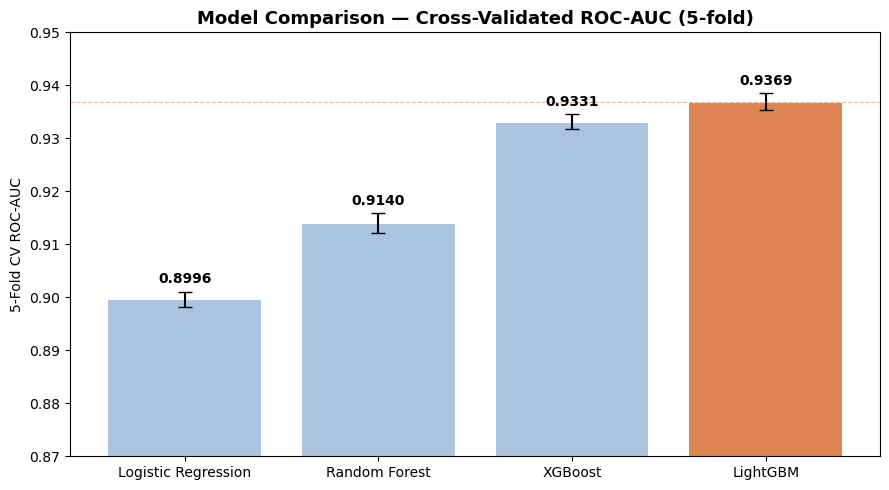

In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, make_scorer, precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import cross_validate, StratifiedKFold
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos = neg / pos
print(f"scale_pos_weight: {scale_pos:.2f}  ({neg:,} normal / {pos:,} H&R)\n")

all_pipelines = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": Pipeline([
        ("prep",  preprocessor),
        ("model", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)),
    ]),
    "XGBoost": Pipeline([
        ("prep",  preprocessor),
        ("model", XGBClassifier(n_estimators=300, scale_pos_weight=scale_pos, random_state=42, n_jobs=-1, eval_metric="auc", verbosity=0)),
    ]),
    "LightGBM": Pipeline([
        ("prep",  preprocessor),
        ("model", LGBMClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1)),
    ]),
}

scoring = {
    "roc_auc":   "roc_auc",
    "accuracy":  "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall":    make_scorer(recall_score),
    "f1":        make_scorer(f1_score),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, pipeline in all_pipelines.items():
    print(f"Evaluating {name}...")
    res = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = res

# Summary table
print("\nCV Results (mean):")
header = f"{'Model':<22} {'ROC-AUC':>10} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>8}"
print(header)
print("-" * len(header))
for name, res in cv_results.items():
    auc  = res["test_roc_auc"].mean()
    acc  = res["test_accuracy"].mean()
    prec = res["test_precision"].mean()
    rec  = res["test_recall"].mean()
    f1   = res["test_f1"].mean()
    print(f"{name:<22} {auc:>10.4f} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>8.4f}")

# Model comparison bar chart
import matplotlib.pyplot as plt
import numpy as np

model_names = list(cv_results.keys())
means = [cv_results[m]["test_roc_auc"].mean() for m in model_names]
stds  = [cv_results[m]["test_roc_auc"].std()  for m in model_names]

colors = ["#aac4e0", "#aac4e0", "#aac4e0", "#DD8452"]  # highlight LightGBM
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(model_names, means, yerr=stds, capsize=5, color=colors,
              edgecolor="white", linewidth=1.5, error_kw={"elinewidth": 1.5})
ax.set_ylim(0.87, 0.95)
ax.set_ylabel("5-Fold CV ROC-AUC")
ax.set_title("Model Comparison — Cross-Validated ROC-AUC (5-fold)", fontsize=13, fontweight="bold")
ax.axhline(means[-1], color="#DD8452", linestyle="--", linewidth=0.8, alpha=0.6)
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.001,
            f"{m:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()


LightGBM achieves the highest cross-validated ROC-AUC (0.937) and is selected for tuning. All four models perform well above random chance. The marginal improvement from LR (0.899) to LightGBM (0.937) suggests that non-linear feature interactions — particularly between temporal and categorical variables — contribute meaningful additional discrimination.


### Hyperparameter Tuning

LightGBM hyperparameters were optimised via `RandomizedSearchCV` (two rounds of 25 iterations across 9 parameters, 5-fold stratified CV). The search code is included below (commented out) for transparency; the best parameters are hardcoded for reproducibility and faster execution.


In [62]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
import scipy.stats as stats

# --- RandomizedSearchCV (commented out to save execution time) ---
# param_dist = {
#     "model__n_estimators":       [500, 700, 1000, 1200],
#     "model__learning_rate":      stats.uniform(0.03, 0.07),
#     "model__num_leaves":         stats.randint(60, 150),
#     "model__max_depth":          [-1, 10, 12, 16],
#     "model__min_child_samples":  stats.randint(20, 80),
#     "model__subsample":          stats.uniform(0.7, 0.3),
#     "model__colsample_bytree":   stats.uniform(0.6, 0.4),
#     "model__reg_alpha":          stats.uniform(0, 1),
#     "model__reg_lambda":         stats.uniform(0, 1),
# }
#
# lgbm_pipe = Pipeline([
#     ("prep",  preprocessor),
#     ("model", LGBMClassifier(class_weight="balanced", random_state=42,
#                               n_jobs=-1, verbose=-1)),
# ])
#
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# search = RandomizedSearchCV(lgbm_pipe, param_distributions=param_dist,
#                              n_iter=25, scoring="roc_auc", cv=cv,
#                              random_state=7, n_jobs=-1, verbose=1)
# search.fit(X_train, y_train)
# best_model = search.best_estimator_

# Best parameters from the search above:
best_params = {
    "n_estimators":      700,
    "learning_rate":     0.04,
    "num_leaves":        80,
    "max_depth":         -1,
    "min_child_samples": 30,
    "subsample":         0.8,
    "colsample_bytree":  0.8,
    "reg_alpha":         0.1,
    "reg_lambda":        0.5,
}

best_model = Pipeline([
    ("prep",  preprocessor),
    ("model", LGBMClassifier(
        **best_params,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )),
])

print("Best hyperparameters (from RandomizedSearchCV):")
for k, v in best_params.items():
    print(f"  {k}: {v}")


Best hyperparameters (from RandomizedSearchCV):
  n_estimators: 700
  learning_rate: 0.04
  num_leaves: 80
  max_depth: -1
  min_child_samples: 30
  subsample: 0.8
  colsample_bytree: 0.8
  reg_alpha: 0.1
  reg_lambda: 0.5


---

## Final Test Set Evaluation

Evaluate on held-out test set. Threshold chosen to favour recall - missed H&R is costlier than a false alarm.


Test ROC-AUC: 0.9380
Best threshold (max F2): 0.306  Precision=0.650  Recall=0.935

              precision    recall  f1-score   support

     Non-H&R       0.96      0.78      0.86     30390
         H&R       0.65      0.93      0.77     13374

    accuracy                           0.83     43764
   macro avg       0.81      0.86      0.81     43764
weighted avg       0.87      0.83      0.83     43764



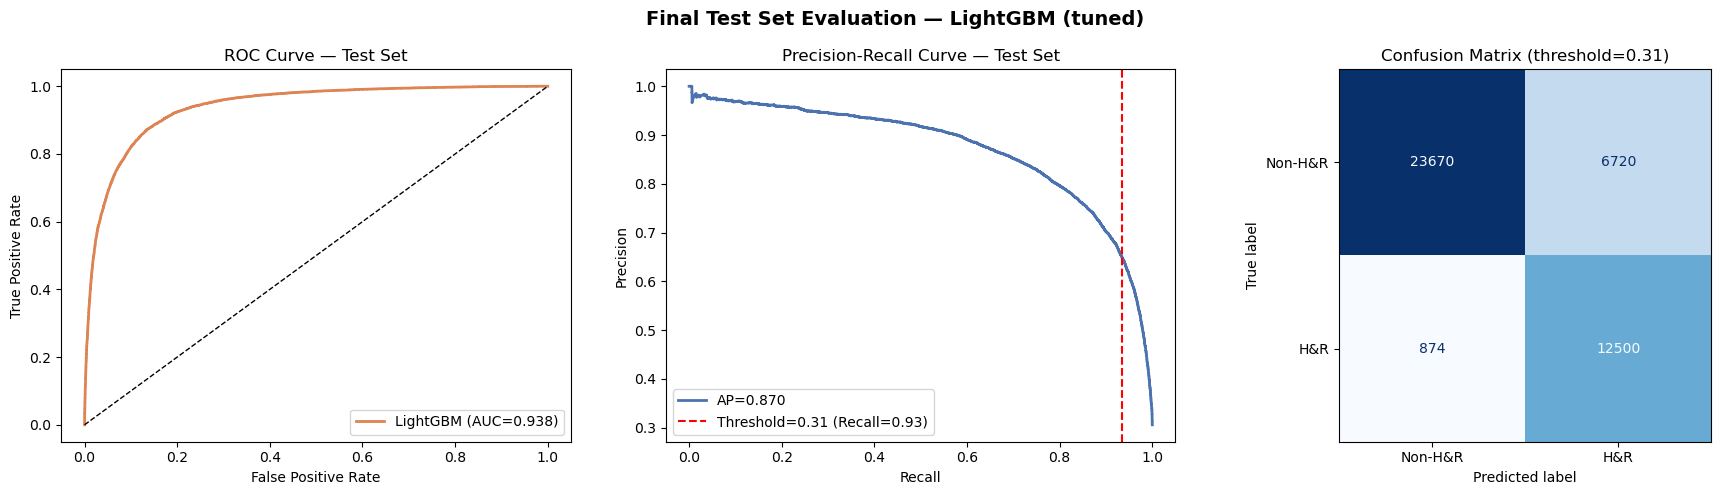

In [63]:
import geopandas as gpd
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Load test set
df_test = gpd.read_parquet(FINAL_TEST_FILE)
df_test = engineer_features(df_test)
X_test  = df_test[FEATURE_COLS]
y_test  = df_test[TARGET_COL]

# Refit best_model (tuned) on full training data
best_model.fit(X_train, y_train)
y_prob = best_model.predict_proba(X_test)[:, 1]

# ROC-AUC
test_auc = roc_auc_score(y_test, y_prob)
print(f"Test ROC-AUC: {test_auc:.4f}")

# Threshold selection: maximise F2 (recall-weighted)
prec, rec, thresholds = precision_recall_curve(y_test, y_prob)
f2 = (5 * prec * rec) / (4 * prec + rec + 1e-9)
best_idx  = f2.argmax()
best_thresh = thresholds[best_idx]
print(f"Best threshold (max F2): {best_thresh:.3f}  "
      f"Precision={prec[best_idx]:.3f}  Recall={rec[best_idx]:.3f}")

y_pred = (y_prob >= best_thresh).astype(int)
print()
print(classification_report(y_test, y_pred, target_names=["Non-H&R", "H&R"]))

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curve
ax = axes[0]
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax.plot(fpr, tpr, color="#DD8452", lw=2, label=f"LightGBM (AUC={test_auc:.3f})")
ax.plot([0,1],[0,1], "k--", lw=1)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Test Set")
ax.legend()

# Precision-Recall curve
ax = axes[1]
ap = average_precision_score(y_test, y_prob)
ax.plot(rec, prec, color="#4C72B0", lw=2, label=f"AP={ap:.3f}")
ax.axvline(rec[best_idx], color="red", ls="--", lw=1.5,
           label=f"Threshold={best_thresh:.2f} (Recall={rec[best_idx]:.2f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — Test Set")
ax.legend()

# Confusion matrix
ax = axes[2]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Non-H&R", "H&R"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix (threshold={best_thresh:.2f})")

plt.suptitle("Final Test Set Evaluation — LightGBM (tuned)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


The tuned LightGBM achieves a test ROC-AUC of 0.938 - near-identical to cross-validation, confirming negligible overfitting. At the F2-optimised threshold of 0.31, recall is 0.935 and precision is 0.65. The relatively low precision is an acceptable cost: reviewing a non-H&R crash is far less costly than missing a real one.


### Feature Importance and Primary Research Question

SHAP analysis is applied to a LightGBM model trained on the full training set.


/Users/yoav.gochman/anaconda3/envs/urbsim/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/Users/yoav.gochman/anaconda3/envs/urbsim/lib/python3.12/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/yoav.gochman/anaconda3/envs/urbsim/lib/python3.12/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


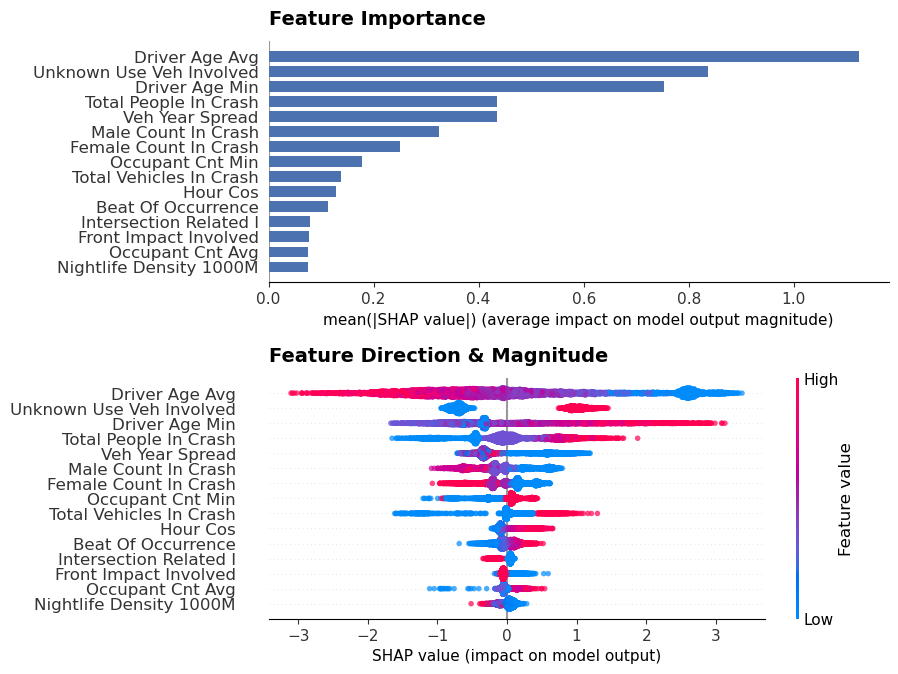

In [64]:
import sys
!{sys.executable} -m pip install shap -q

import shap
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import matplotlib as mpl

# Fit LightGBM on full train set for SHAP
lgbm_shap = Pipeline([
    ("prep",  preprocessor),
    ("model", LGBMClassifier(n_estimators=300, class_weight="balanced",
                              random_state=42, n_jobs=-1, verbose=-1)),
])
lgbm_shap.fit(X_train, y_train)

X_train_transformed = lgbm_shap[:-1].transform(X_train)
feature_names = X_train_transformed.columns.tolist()

explainer = shap.TreeExplainer(lgbm_shap["model"])
sample_idx = X_train_transformed.sample(5000, random_state=42).index
shap_values = explainer.shap_values(X_train_transformed.loc[sample_idx])
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

# Clean feature names for display
display_names = [n.replace('_', ' ').title() for n in feature_names]

# vertical — Stacked: bar chart (top) + beeswarm (bottom)
with mpl.rc_context({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
}):
    fig, axes = plt.subplots(2, 1, figsize=(12, 20),
                             gridspec_kw={'hspace': 0.4})

    plt.sca(axes[0])
    shap.summary_plot(sv, X_train_transformed.loc[sample_idx],
                      feature_names=display_names, plot_type="bar",
                      max_display=15, show=False, color='#4C72B0')
    axes[0].set_title('Feature Importance', fontweight='bold', fontsize=14,
                      loc='left', pad=12)
    axes[0].tick_params(axis='y', labelsize=12)
    axes[0].tick_params(axis='x', labelsize=11)
    axes[0].set_xlabel(axes[0].get_xlabel(), fontsize=11)

    plt.sca(axes[1])
    shap.summary_plot(sv, X_train_transformed.loc[sample_idx],
                      feature_names=display_names, max_display=15,
                      show=False, alpha=0.7)
    axes[1].set_title('Feature Direction & Magnitude', fontweight='bold',
                      fontsize=14, loc='left', pad=12)
    axes[1].tick_params(axis='y', labelsize=12)
    axes[1].tick_params(axis='x', labelsize=11)
    axes[1].set_xlabel(axes[1].get_xlabel(), fontsize=11)

    plt.show()


> **Reading the beeswarm:** each dot is one crash. Colour = that feature's value (red = high, blue = low). Position = SHAP contribution (right = pushes toward H&R, left = pushes away). For example, `Driver Age Avg`: blue dots (age = 0, no one at scene) push right toward H&R; red dots (older driver present) push left away from H&R.


Two feature clusters dominate:

**1. Witness/victim absence.** `Driver Age Avg` ranks first — age = 0 means no person was recorded at scene (40.9% of H&R vs 6.4% non-H&R). `Unknown Use Veh Involved` (rank 2) flags vehicles that fled before documentation. `Total People In Crash` and gender counts reinforce: fewer people = stronger H&R signal.

**2. Temporal anonymity.** `Hour Cos` captures the deep-night window (00:00–04:00) — fewer witnesses and lower enforcement.

Among the top 15 features displayed, `Nightlife Density 1000m` ranks lowest. Its high values (red dots) tend to push slightly *away* from H&R — the opposite of what the nightlife hypothesis would predict. According to our model, nightlife proximity is not an independent predictor of H&R once behavioural and temporal features are controlled for.


---

## Spatial Error Analysis

**Secondary research question:** Do prediction errors cluster spatially? The recall choropleth maps detection rate across Chicago's police beats (beats with fewer than five H&R crashes excluded). Beat-level recall is tested for spatial autocorrelation via Local Moran's I.


In [65]:
import geopandas as gpd
import pandas as pd
import numpy as np

df_eval = df_test[["beat_of_occurrence", TARGET_COL]].copy()
df_eval["beat_of_occurrence"] = pd.to_numeric(df_eval["beat_of_occurrence"], errors="coerce").astype("Int64").astype(str)
df_eval["y_pred"] = y_pred

def beat_metrics(grp):
    y_true = grp[TARGET_COL]
    y_hat  = grp["y_pred"]
    tp = ((y_true == 1) & (y_hat == 1)).sum()
    fn = ((y_true == 1) & (y_hat == 0)).sum()
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    n_hnr  = tp + fn
    return pd.Series({"recall": recall, "n_hnr": n_hnr, "n_crashes": len(grp)})

beat_stats = (df_eval.groupby("beat_of_occurrence")
                     .apply(beat_metrics)
                     .reset_index())

beat_stats = beat_stats[beat_stats["n_hnr"] >= 5].copy()
beat_stats["beat_of_occurrence"] = pd.to_numeric(beat_stats["beat_of_occurrence"], errors="coerce").astype("Int64").astype(str)

BEAT_FILE = "PoliceBeatDec2012.geojson"
if not os.path.exists(BEAT_FILE):
    print("Downloading police-beat boundaries from GitHub...")
    import urllib.request
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/casagochman/chicago-hit-and-run/main/multi_ds/PoliceBeatDec2012_20260412.geojson",
        BEAT_FILE)
    print(f"  Saved {BEAT_FILE}")
beats_gdf = gpd.read_file(BEAT_FILE)[["beat_num", "geometry"]].copy()
beats_gdf["beat_of_occurrence"] = beats_gdf["beat_num"].astype(float).astype(int).astype(str)
beats_gdf = beats_gdf.to_crs("EPSG:26916")

beats_merged = beats_gdf.merge(beat_stats, on="beat_of_occurrence", how="left")

cx = beats_merged.geometry.centroid.x
cy = beats_merged.geometry.centroid.y
outliers = beats_merged[(cx < 400000) | (cx > 470000) | (cy < 4600000) | (cy > 4680000)]
if len(outliers) > 0:
    beats_merged = beats_merged[~beats_merged.index.isin(outliers.index)]

print(f"Beats with metrics: {beats_merged['recall'].notna().sum()}")


Beats with metrics: 271


/var/folders/vr/69185f_n1jd4wr0p8145ps1m8zr63m/T/ipykernel_85451/3479486545.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(beat_metrics)


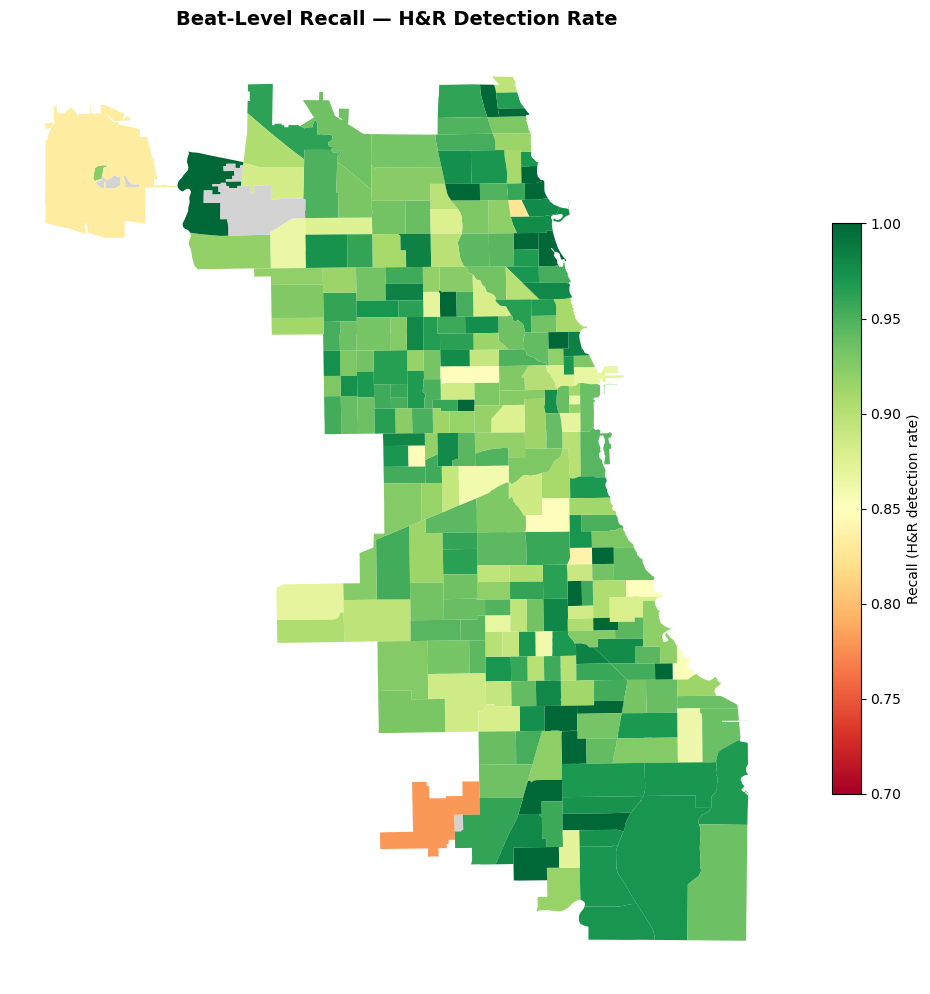

In [66]:
import matplotlib.pyplot as plt

MISSING = {"color": "lightgrey", "label": "Insufficient data (< 5 H&R crashes)"}

fig, ax = plt.subplots(figsize=(10, 10))
beats_merged.plot(
    column="recall", ax=ax, cmap="RdYlGn",
    vmin=0.7, vmax=1.0, legend=True, missing_kwds=MISSING,
    legend_kwds={"label": "Recall (H&R detection rate)", "shrink": 0.6}
)
ax.set_title("Beat-Level Recall — H&R Detection Rate", fontsize=14, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()


### Local Moran's I (LISA): Identifying Recall Blind Spots

LISA identifies *where* spatial clustering occurs. We focus on **Low-Low clusters**: beats with below-average recall surrounded by similarly below-average neighbours — the model's geographic blind spots. Each beat is classified by its LISA quadrant.


Beats included: 271


/var/folders/vr/69185f_n1jd4wr0p8145ps1m8zr63m/T/ipykernel_85451/3609349195.py:13: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(beats_valid, silence_warnings=True)


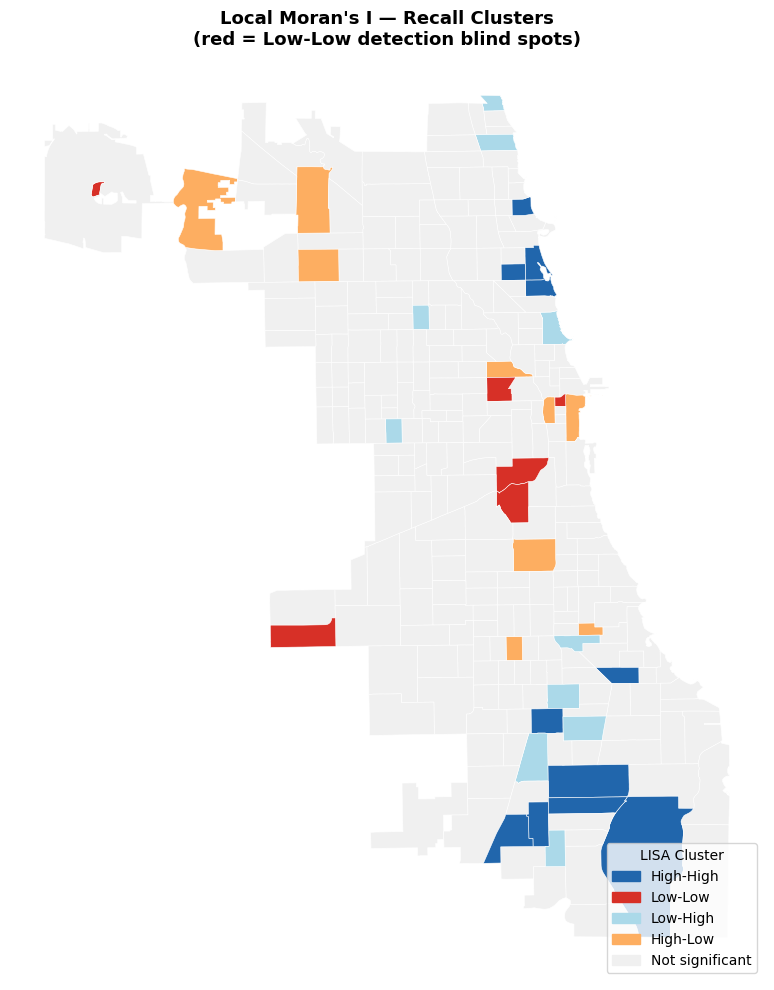


Significant Low-Low beats: 6
beat_of_occurrence   recall  n_hnr
              1651 0.923077   13.0
              1215 0.926829   41.0
               111 0.911111   45.0
              1235 0.929577   71.0
               913 0.886364   44.0
               812 0.904762   42.0


In [67]:
import sys
!{sys.executable} -m pip install esda -q

from libpysal.weights import Queen
from esda.moran import Moran_Local
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

beats_valid = beats_merged[beats_merged["recall"].notna()].copy().reset_index(drop=True)
print(f"Beats included: {len(beats_valid)}")

w = Queen.from_dataframe(beats_valid, silence_warnings=True)
w.transform = "r"

lisa = Moran_Local(beats_valid["recall"].values, w, permutations=999, seed=42)

cluster_labels = {1: "High-High", 2: "Low-High", 3: "Low-Low", 4: "High-Low"}
beats_valid["cluster"] = [
    cluster_labels.get(q, "Not significant") if p < 0.05 else "Not significant"
    for q, p in zip(lisa.q, lisa.p_sim)
]

color_map = {
    "High-High":       "#2166ac",
    "Low-Low":         "#d73027",
    "Low-High":        "#abd9e9",
    "High-Low":        "#fdae61",
    "Not significant": "#f0f0f0",
}

fig, ax = plt.subplots(figsize=(10, 10))
beats_valid.plot(color=beats_valid["cluster"].map(color_map),
                 ax=ax, edgecolor="white", linewidth=0.4)
patches = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
ax.legend(handles=patches, loc="lower right", fontsize=10, title="LISA Cluster")
ax.set_title("Local Moran's I — Recall Clusters\n(red = Low-Low detection blind spots)",
             fontsize=13, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

ll = beats_valid[beats_valid["cluster"] == "Low-Low"]
print(f"\nSignificant Low-Low beats: {len(ll)}")
if len(ll) > 0:
    print(ll[["beat_of_occurrence", "recall", "n_hnr"]].to_string(index=False))
else:
    print("No significant Low-Low clusters — detection failures are not geographically concentrated.")


Beat-level recall is high and uniform (mean = 0.937, std = 0.039, min = 0.780). LISA identifies **six beats forming a significant Low-Low cluster** with below-average recall (0.886–0.930), but even these detect 88–93% of H&R crashes — relative underperformance, not blind spots. The single worst beat (0.780) is a spatial outlier, not part of a systematic failure zone.

**Answer to secondary research question:** The model's misses are driven by crash-level features, not location. No operationally meaningful geographic blind spots exist.


## Conclusion

Nightlife proximity contributes negligible independent predictive value for H&R classification. The dominant predictors - witness absence, unidentifiable vehicle information, late-night timing, and crash geometry — reflect structural opportunity for undetected flight rather than proximity to alcohol-serving venues. Local Moran's I confirms that detection failures are feature-driven, not geography-driven.

Key limitations include the observational design (no causal inference) and the dominance of property-damage-only H&R (87.4%), which tunes the model primarily to opportunistic parked-vehicle scenarios. Future work should develop sub-type-specific classifiers for pedestrian and cyclist H&R, and apply causal identification strategies. **Graph Neural Networks** offer a natural extension: encoding beat adjacency as a graph could capture cross-beat spillover effects invisible to independent beat-level models.


## References

City of Chicago (2025a). *Traffic Crashes — Crashes*. Chicago Data Portal. https://data.cityofchicago.org/Transportation/Traffic-Crashes-Crashes/85ca-t3if/about_data

City of Chicago (2025b). *Traffic Crashes — Vehicles*. Chicago Data Portal. https://data.cityofchicago.org/Transportation/Traffic-Crashes-Vehicles/68nd-jvt3/about_data

City of Chicago (2025c). *Traffic Crashes — People*. Chicago Data Portal. https://data.cityofchicago.org/Transportation/Traffic-Crashes-People/u6pd-qa9d/about_data

City of Chicago (2025d). *Business Licenses*. Chicago Data Portal. https://data.cityofchicago.org/Community-Economic-Development/Business-Licenses/r5kz-chrr/about_data

Han, B. et al. (2025) "Investigating the contributors to hit-and-run crashes using gradient boosting decision trees," *PLOS ONE*, 20(1), p. e0314939. Available at: https://doi.org/10.1371/journal.pone.0314939.

Kim, K., Pant, P. and Yamashita, E. (2008) "Hit-and-Run Crashes: Use of Rough Set Analysis with Logistic Regression to Capture Critical Attributes and Determinants," *Transportation Research Record*, 2083, pp. 114–121. Available at: https://doi.org/10.3141/2083-13.

Solnick, S.J. and Hemenway, D. (1995) "The hit-and-run in fatal pedestrian accidents: victims, circumstances and drivers," *Accident Analysis & Prevention*, 27(5), pp. 643–649. Available at: https://doi.org/10.1016/0001-4575(95)00012-o.

Tay, R., Barua, U. and Kattan, L. (2009) "Factors contributing to hit-and-run in fatal crashes," *Accident Analysis & Prevention*, 41(2), pp. 227–233. Available at: https://doi.org/10.1016/j.aap.2008.11.002.
